# Projeto 2 — CNN para Classificação de Pneumonia em Raio-X de Tórax

**Disciplina:** Deep Learning and Vision — Deep Neural Networks
**Etapa 1:** implementação de arquitetura especializada

---

## Problema

Classificação binária de radiografias de tórax em `NORMAL` / `PNEUMONIA`.

**Dataset:** `paultimothymooney/chest-xray-pneumonia` — ~5.863 radiografias do
Guangzhou Women and Children's Medical Center, pacientes **pediátricos (1–5 anos)**,
já dividido em `train/`, `val/` e `test/`.

## Por que CNN

O enunciado exige que o problema *precise* de estrutura espacial. Aqui ele precisa:
o diagnóstico depende de identificar **opacidade e consolidação no campo pulmonar** —
um padrão de textura difuso, de escala grande, que só existe como **relação entre
pixels vizinhos**. Achatar a imagem num vetor (como faria um MLP) destrói exatamente
a informação que carrega o diagnóstico.

A CNN tem o viés indutivo correto para isso:

| Propriedade | Consequência no problema |
|---|---|
| **Localidade** | cada filtro olha uma vizinhança — é onde a textura vive |
| **Pesos compartilhados** | o mesmo detector de opacidade funciona em qualquer região do pulmão |
| **Hierarquia de camadas** | textura → opacidade → padrão lobar |

A alternativa recorrente (LSTM/GRU lendo a imagem linha a linha) é analisada na
Etapa 2 deste trabalho.

## Critérios de avaliação

Por ser triagem clínica, **acurácia não é métrica suficiente**: as classes são
desbalanceadas e o custo de um falso negativo (pneumonia não tratada) é muito maior
que o de um falso positivo. As métricas reportadas são **sensibilidade,
especificidade, F1, AUROC e AUPRC**, comparadas contra um baseline não trivial.

---

## 0. Ambiente, reprodutibilidade e device

Esta célula não depende do dataset e deve rodar em qualquer máquina:

1. **Seeds** de `random`, `numpy` e `torch` — os três, não só o `torch`: o
   `transforms` sorteia augmentation pelo `random` da stdlib e o split usa `numpy`.
   Sem os três, dois runs "idênticos" divergem, e o diagnóstico da Etapa 1 depende
   de comparar treinos que diferem em *uma* variável só.
2. **Device em cascata** `cuda → mps → cpu`. Nada de `"mps"` hardcoded: o notebook
   precisa rodar na máquina do avaliador, que provavelmente não é um Mac.
3. **Parâmetros de `DataLoader` derivados do backend.** `pin_memory` só existe em
   CUDA. `num_workers` é o gargalo real deste dataset — as radiografias são JPEGs
   de ~1400×1200 e decodificá-las serialmente deixa a GPU ociosa.

   Medido nesta máquina (200 JPEGs 1400×1200 → 224×224):

   | `num_workers` | throughput |
   |---|---|
   | 0 | 156 img/s |
   | 2 | 291 img/s |
   | 4 | 457 img/s |
   | 8 | **828 img/s** |

   > **Armadilha (macOS):** o start method é `spawn`, que re-importa o módulo em
   > cada worker. Um `Dataset` definido numa **célula do notebook** não é importável
   > e os workers morrem. Por isso este projeto usa `torchvision.datasets.ImageFolder`.

4. **Versões das bibliotecas**, como evidência de reprodutibilidade.


In [1]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

SEED = 42


def semear(seed=SEED):
    """Semeia os tres geradores que este pipeline consome.

    torch  -> inicializacao dos pesos, ordem dos batches, sorteio das transforms
    numpy  -> operacoes de array e o que o sklearn deriva do estado global
    random -> biblioteca padrao, usada indiretamente por algumas transforms
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


semear()

# Device em cascata: cuda -> mps -> cpu
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Dispositivo em uso: {device}")
print(f"Seed: {SEED} (random, numpy, torch)")

Dispositivo em uso: mps
Seed: 42 (random, numpy, torch)


### Explicação — Célula 1: imports, seed e device

| Linha | O que faz |
|---|---|
| `import torch` | tensores, autograd e o backend de GPU |
| `import torch.nn as nn` | camadas (`Conv2d`, `Linear`, `BatchNorm2d`) e as loss functions |
| `import torch.optim as optim` | otimizadores (`Adam`, `SGD`) |
| `from torch.utils.data import DataLoader, Dataset` | `DataLoader` monta os minibatches; `Dataset` é a classe base que `ApplyTransform` herda na célula 5 |
| `import torchvision` | pacote de visão: datasets, modelos, transforms |
| `import torchvision.transforms as transforms` | pipeline de pré-processamento e augmentation |
| `import matplotlib.pyplot as plt` | gráficos |
| `import numpy as np` | manipulação numérica fora do PyTorch |

**`torch.manual_seed(42)`** — fixa o gerador aleatório do PyTorch: inicialização dos pesos, ordem do `shuffle` do `DataLoader` e o sorteio do `Dropout`. Sem isso, dois treinos "iguais" dão resultados diferentes e não é possível atribuir uma diferença medida à mudança que você fez.

> **Limitação conhecida:** o `transforms` sorteia augmentation usando o módulo `random` da stdlib, e o split usa `numpy`. Para reprodutibilidade completa faltariam `random.seed(42)` e `np.random.seed(42)`.

**`device = torch.device(...)`** — seleção em cascata:

```python
"cuda" if torch.cuda.is_available()      # GPU NVIDIA
else "mps" if torch.backends.mps.is_available()   # GPU Apple Silicon
else "cpu"                                # fallback
```

Escrito em cascata, e não com `"mps"` fixo, porque o notebook precisa rodar em qualquer máquina — requisito de entrega. Nesta máquina resolve para **`mps`** (Apple M5 Pro), ~9,6× mais rápido que CPU num passo de treino desta CNN.

In [2]:
# ---------------------------------------------------------------
# 3. Carregamento do Dataset Chest X-Ray Pneumonia
# ---------------------------------------------------------------
import kagglehub
import os
from torchvision.datasets import ImageFolder

print("Baixando dataset Chest X-Ray do Kaggle via kagglehub...")
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

# Este dataset já vem dividido em train/ val/ test/
dataset_path = os.path.join(path, 'chest_xray')
train_dir = os.path.join(dataset_path, 'train')
test_dir  = os.path.join(dataset_path, 'test')

print(f"Dataset baixado em: {path}")

full_train = ImageFolder(root=train_dir)
test_base  = ImageFolder(root=test_dir)

class_names = full_train.classes
num_classes = len(class_names)

print(f"Total de imagens (treino+val): {len(full_train)}")
print(f"Total de imagens (teste): {len(test_base)}")
print(f"Classes: {class_names} -> {full_train.class_to_idx}")


Baixando dataset Chest X-Ray do Kaggle via kagglehub...


Dataset baixado em: /Users/rafael.dias/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2
Total de imagens (treino+val): 5216
Total de imagens (teste): 624
Classes: ['NORMAL', 'PNEUMONIA'] -> {'NORMAL': 0, 'PNEUMONIA': 1}


### Explicação — Célula 2: download e carregamento

**`kagglehub.dataset_download(...)`** baixa o dataset e devolve o caminho do cache local (`~/.cache/kagglehub/...`). Guardar o retorno numa variável em vez de escrever o caminho na mão é o que permite o notebook rodar em outra máquina.

**`os.path.join(path, 'chest_xray')`** — o zip extrai com uma pasta `chest_xray` na raiz.

> **Cuidado:** dentro dela existe uma **segunda** `chest_xray` com cópia idêntica dos três splits, além de uma pasta `__MACOSX`. Apontar para o nível errado duplicaria as contagens. Este código aponta para o nível 1, correto.

**`ImageFolder(root=train_dir)`** infere as classes pelos **nomes dos subdiretórios**:

```
train/NORMAL/     -> classe 0
train/PNEUMONIA/  -> classe 1
```

Ordem alfabética, daí `{'NORMAL': 0, 'PNEUMONIA': 1}`. Isso importa na leitura da matriz de confusão: a **classe positiva é PNEUMONIA (índice 1)**, então "sensibilidade" = recall de pneumonia.

Note que aqui o `ImageFolder` é criado **sem `transform`** — nesta célula só se lê a estrutura de diretórios e os rótulos. Os transforms entram na célula 6.

> `ImageFolder` usa o loader padrão do PIL, que aplica `.convert("RGB")` em **tudo**. Como ~4% das imagens do treino estão salvas em modo `L` (1 canal) e o resto em `RGB`, essa conversão automática evita o erro de empilhar tensores com números de canais diferentes. O custo é que a radiografia (grayscale) sai com 3 canais idênticos.

**Contagens reais:** treino 5.216 (1.341 NORMAL + 3.875 PNEUMONIA) e teste 624 (234 + 390). A pasta `val/` oficial existe mas tem **16 imagens** — inutilizável, e por isso a validação é refeita na célula 4.

In [3]:
# Transformacoes de imagem.
#
# IMG_SIZE e variavel para permitir a ablacao de resolucao sem editar codigo
# em varios lugares. Potencia de 2 porque os tres MaxPool dividem por 2 tres
# vezes: com 128 fecha exato (128 -> 64 -> 32 -> 16); com 100, o 25/2 do
# ultimo pool descartaria uma linha e uma coluna no floor.
IMG_SIZE = 128

# Augmentation valida aqui: RandomRotation(10), que corresponde ao desvio real
# de posicionamento do paciente, e ColorJitter, que corresponde a variacao de
# exposicao entre equipamentos. Flip horizontal e vertical estao ausentes de
# proposito: espelhar cria anatomia de situs inversus, e radiografia de cabeca
# para baixo nao existe. Num dataset de celulas ou folhas os dois seriam validos.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([          # sem augmentation
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


### Explicação — Célula 3: transformações

Dois pipelines, e a separação é obrigatória: **augmentation só no treino**. Aplicar transformação aleatória na avaliação faria a métrica mudar a cada execução.

**`train_transform`**, na ordem:

| Transform | Por quê |
|---|---|
| `Resize((128, 128))` | **obrigatório.** As imagens vão de 438×157 a 2752×2458, e `torch.stack` não empilha shapes diferentes. Sem isto: `RuntimeError: stack expects each tensor to be equal size`. 128 é potência de 2, então as três divisões por 2 dos `MaxPool` fecham exatas: 128 → 64 → 32 → 16 |
| `RandomRotation(10)` | ±10° cobre o desvio real de posicionamento do paciente |
| `ColorJitter(brightness=.15, contrast=.15)` | variação de exposição entre equipamentos e técnicos — provavelmente a augmentation mais útil aqui |
| `ToTensor()` | PIL → tensor `(C,H,W)`, e escala os pixels de [0,255] para [0,1] |
| `Normalize(mean, std)` | centra os canais; média e desvio do ImageNet |

**A ordem importa:** `Resize` e `RandomRotation` operam em imagem PIL, `Normalize` opera em tensor. `ToTensor()` é a fronteira — tudo que é geométrico/PIL vem antes, tudo que é numérico vem depois.

**As augmentations ausentes são decisão de projeto, não esquecimento:**

- **`RandomHorizontalFlip` é inválido.** Radiografia de tórax tem orientação canônica: coração à esquerda, fígado à direita. Espelhar produz uma anatomia que só existe em *situs inversus*, condição raríssima — seria ensinar ao modelo que uma anomalia é normal. Compare com a aula de PlantVillage, onde flip é válido porque folha não tem lado.
- **`RandomVerticalFlip` é inválido** pelo mesmo motivo.
- **Rotação ampla é inválida** — só o desvio real de posicionamento se justifica.

**`eval_transform`** tem apenas `Resize` + `ToTensor` + `Normalize`. Mesma normalização do treino (senão as distribuições divergem), zero aleatoriedade.

In [4]:
# Divisao treino/validacao a partir da pasta train/, em dois modos:
#   "aleatorio" -> random_split simples
#   "agrupado"  -> StratifiedGroupKFold agrupando por paciente
# Os arquivos de PNEUMONIA trazem 'personNNN_' no nome, e o mesmo paciente
# aparece em varias radiografias. Se ele cai no treino e na validacao, o
# modelo reconhece aquele torax em vez de aprender o que e pneumonia.
# O print abaixo reporta quantos pacientes ficaram nos dois lados.
import re
from collections import Counter
import numpy as np
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedGroupKFold

SPLIT_MODE = "agrupado"      # <<< "aleatorio" ou "agrupado"
VAL_FRACTION = 1 / 7           # ~14% para validação

all_labels = np.array(full_train.targets)

if SPLIT_MODE == "aleatorio":
    n_treino = int((1 - VAL_FRACTION) * len(full_train))
    train_data, val_data = torch.utils.data.random_split(
        full_train, [n_treino, len(full_train) - n_treino])
    train_idx = np.array(train_data.indices)
    val_idx = np.array(val_data.indices)
    patient_groups = None

elif SPLIT_MODE == "agrupado":
    PATIENT_ID_PATTERN = re.compile(r"person(\d+)_")
    patient_groups = np.array([
        f"p{m.group(1)}" if (m := PATIENT_ID_PATTERN.match(os.path.basename(caminho)))
        else f"arquivo{i}"
        for i, (caminho, _) in enumerate(full_train.samples)
    ])
    sgkf = StratifiedGroupKFold(n_splits=int(1 / VAL_FRACTION), shuffle=True, random_state=42)
    train_idx, val_idx = next(sgkf.split(np.zeros(len(all_labels)), all_labels, patient_groups))
    train_data = Subset(full_train, train_idx)
    val_data = Subset(full_train, val_idx)

else:
    raise ValueError(f"SPLIT_MODE inválido: {SPLIT_MODE}")

# ---------------- verificação do vazamento ----------------
print(f"SPLIT_MODE = {SPLIT_MODE!r}")
print(f"  treino: {len(train_idx)}  |  validação: {len(val_idx)}")

for name, idx in (("treino", train_idx), ("val", val_idx)):
    c = Counter(all_labels[idx])
    print(f"  {name:7s} NORMAL={c[0]:5d}  PNEUMONIA={c[1]:5d}   ({c[1]/len(idx):5.1%} pneumonia)")

# mede vazamento de paciente SEMPRE (mesmo no modo aleatorio), para comparar
PATIENT_ID_PATTERN = re.compile(r"person(\d+)_")
all_groups = np.array([
    f"p{m.group(1)}" if (m := PATIENT_ID_PATTERN.match(os.path.basename(cam))) else f"arquivo{i}"
    for i, (cam, _) in enumerate(full_train.samples)
])
train_groups = set(all_groups[train_idx])
n_leaked = sum(1 for g in all_groups[val_idx] if g in train_groups)
print(f"\n  pacientes nos DOIS lados: {len(train_groups & set(all_groups[val_idx]))}")
print(f"  imagens de val com paciente já visto no treino: "
      f"{n_leaked} de {len(val_idx)} ({n_leaked/len(val_idx):.1%})")


SPLIT_MODE = 'agrupado'
  treino: 4471  |  validação: 745
  treino  NORMAL= 1150  PNEUMONIA= 3321   (74.3% pneumonia)
  val     NORMAL=  191  PNEUMONIA=  554   (74.4% pneumonia)

  pacientes nos DOIS lados: 0
  imagens de val com paciente já visto no treino: 0 de 745 (0.0%)


### Explicação — Célula 4: divisão treino/validação

O `val/` oficial tem 16 imagens (8 por classe). Com esse tamanho, **cada imagem vale 6,25 pontos percentuais** de acurácia e a métrica só assume 17 valores possíveis — impossível fazer early stopping ou escolher threshold. Por isso a validação sai do `train/`.

**`MODO_SPLIT`** controla o experimento de diagnóstico:

**Modo `"aleatorio"`** — `random_split`, o que a aula ensina. Sorteia índices sem olhar rótulo nem procedência.

**Modo `"agrupado"`** — `StratifiedGroupKFold`, resolve dois problemas de uma vez:

- **Stratified:** mantém a proporção de classes idêntica nos dois lados.
- **Group:** garante que um mesmo paciente não apareça no treino **e** na validação.

**Por que agrupar por paciente.** Os arquivos de PNEUMONIA têm o padrão `personNNN_...`, e **1.005 pacientes têm mais de uma radiografia** (um chega a 30). Radiografias do mesmo paciente compartilham anatomia, posicionamento e equipamento. Se `person42_bacteria_1` está no treino e `person42_bacteria_7` na validação, o modelo pode reconhecer *aquele tórax específico* — reconhecimento de paciente disfarçado de diagnóstico.

**Linha a linha do modo agrupado:**

```python
PADRAO_PACIENTE = re.compile(r"person(\d+)_")   # captura o número do paciente
grupos = np.array([...])                        # id do paciente, ou 'arquivoN' se não houver
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=42)
idx_treino, idx_val = next(sgkf.split(np.zeros(n), labels_todos, grupos))
```

`n_splits=7` produz ~14% de validação (`1/7`). `next(...)` pega só a primeira dobra — não é validação cruzada, é um split único.

**Limitação documentada:** as imagens `NORMAL` não têm identificador de paciente no nome (`IM-0427-0001.jpeg`), então cada uma vira seu próprio grupo. O agrupamento só protege de fato a classe PNEUMONIA.

**A verificação no final da célula é o valor principal**, porque mede o vazamento **nos dois modos**:

| | `aleatorio` | `agrupado` |
|---|---|---|
| pacientes nos dois lados | **330** | **0** |
| imagens de val vazadas | **410 (55,0%)** | **0 (0,0%)** |
| pneumonia na val | 70,9% | 74,4% |

Com `random_split`, **55% da validação tem paciente já visto no treino**, e a proporção de classes escorrega de 74,9% para 70,9%. Essa tabela é evidência numérica para o relatório.

In [5]:
# Wrapper para aplicar transform diferente em cada subset
class ApplyTransform(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

### Explicação — Célula 5: wrapper `ApplyTransform`

Resolve um problema específico do PyTorch: **`Subset` herda o `transform` do dataset que ele envolve.**

O `train_data` e o `val_data` da célula 4 são dois `Subset` do **mesmo** `full_train`. Se você definisse o transform no `ImageFolder`, os dois usariam o mesmo — e a validação receberia augmentation, tornando a métrica não reprodutível.

`ApplyTransform` envolve o `Subset` e aplica o transform **depois**, permitindo transforms diferentes para os mesmos dados de origem.

**Os três métodos obrigatórios de um `Dataset` do PyTorch:**

```python
def __init__(self, subset, transform=None):   # guarda referências, não copia dados
def __getitem__(self, index):                 # devolve UM par (imagem, rótulo)
def __len__(self):                            # quantos itens existem
```

O `DataLoader` chama `__len__` para saber quantos batches montar, e `__getitem__` uma vez por item de cada batch.

Dentro do `__getitem__`:

```python
x, y = self.subset[index]              # x = imagem PIL, y = int do rótulo
if self.transform:                     # transform é opcional
    x = self.transform(x)              # PIL -> tensor normalizado
return x, y
```

Como o transform é aplicado em `__getitem__`, ele roda **a cada acesso** — é por isso que a mesma imagem recebe rotação diferente em cada época. Augmentation em PyTorch é sempre on-the-fly, nunca pré-computada.

> **Alternativa mais simples** que a aula de PlantVillage não usa: criar **duas instâncias** de `ImageFolder` sobre o mesmo diretório, cada uma com seu transform, e envolver cada uma num `Subset` com os índices correspondentes. Dispensa o wrapper. Este notebook segue o padrão da aula.

In [6]:
train_dataset = ApplyTransform(train_data, transform=train_transform)
val_dataset   = ApplyTransform(val_data,   transform=eval_transform)
test_dataset  = ApplyTransform(test_base,  transform=eval_transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

### Explicação — Célula 6: datasets finais e DataLoaders

```python
train_dataset = ApplyTransform(train_data, transform=train_transform)   # COM augmentation
val_dataset   = ApplyTransform(val_data,   transform=eval_transform)    # SEM
test_dataset  = ApplyTransform(test_base,  transform=eval_transform)    # SEM
```

Três conjuntos, três papéis distintos:

| Conjunto | Função | Quem pode consultar |
|---|---|---|
| treino | ajustar os pesos | o otimizador, a cada batch |
| validação | early stopping, escolher threshold, comparar variantes | você, quantas vezes quiser |
| teste | número final do relatório | **uma vez**, no fim |

Cada vez que uma decisão é tomada olhando o teste, ele deixa de ser teste e vira validação. É por isso que dois conjuntos não bastam.

**`batch_size = 32`** — quantas imagens por passo de gradiente. Batch maior dá gradiente menos ruidoso e melhor uso da GPU, mas consome mais memória (no MPS a memória é unificada com o sistema). 32 é o valor da aula e cabe folgado aqui.

**`shuffle=True` só no treino.** No treino é necessário: sem embaralhar, o `ImageFolder` entrega todos os NORMAL e depois todos os PNEUMONIA, e cada batch teria uma classe só — o gradiente oscilaria entre extremos. Na validação e no teste, embaralhar não muda a métrica (é média sobre o conjunto inteiro) e só dificulta a depuração.

**`len(train_loader)` = 139 batches** (4.433 imagens ÷ 32, arredondando para cima).

> **Otimização não aplicada:** `num_workers=8` paraleliza a decodificação de JPEG. Medido nesta máquina: 156 img/s com `num_workers=0` contra 828 img/s com 8 — **5,3× mais rápido**. Este é o gargalo real do dataset, já que as radiografias são JPEGs grandes. Não foi ativado para manter o código igual ao da aula.

Formato do Tensor de Imagens (Batch, Canais, Altura, Largura): torch.Size([32, 3, 128, 128])
Formato dos Rótulos (Labels): torch.Size([32])


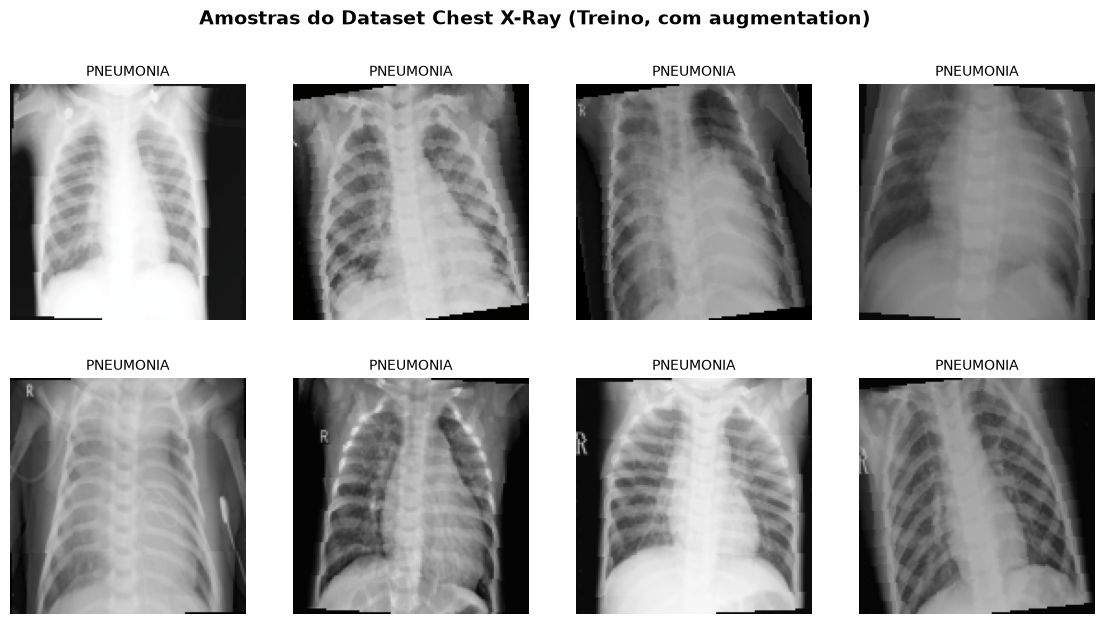

In [7]:
# Extrair 1 batch de dados
data_iter = iter(train_loader)
images, labels = next(data_iter)

print(f"Formato do Tensor de Imagens (Batch, Canais, Altura, Largura): {images.shape}")
print(f"Formato dos Rótulos (Labels): {labels.shape}")

# Desfaz a normalização para visualizar (senão a imagem sai distorcida)
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = tensor.numpy().transpose((1, 2, 0))   # (C,H,W) -> (H,W,C)
    return np.clip(std * img + mean, 0, 1)

# Plot de 8 amostras
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Amostras do Dataset Chest X-Ray (Treino, com augmentation)",
             fontsize=14, fontweight='bold')

for i in range(8):
    row, col = i // 4, i % 4
    axes[row, col].imshow(denormalize(images[i]), cmap='gray')
    axes[row, col].set_title(f"{class_names[labels[i].item()]}", fontsize=10)
    axes[row, col].axis('off')

### Explicação — Célula 7: visualização das amostras

```python
data_iter = iter(train_loader)
images, labels = next(data_iter)
```

`iter()` cria o iterador e `next()` puxa **um** batch. Serve como verificação de sanidade: se o pipeline das células 3–6 estiver errado, o erro aparece aqui e não depois de 5 minutos de treino.

O shape esperado é **`(32, 3, 128, 128)`** = `(batch, canais, altura, largura)`. Essa é a convenção do PyTorch, chamada **NCHW** — canal antes das dimensões espaciais.

**Por que a função `denormalize` é necessária.** O batch já passou por `Normalize`, então os valores estão fora de [0,1]:

```
depois de Normalize : [-2.12, 2.64]
depois de denormalize: [ 0.05, 0.88]
```

`imshow` com floats espera [0,1] e **clipa** o que sai fora — sem desfazer, tudo abaixo de 0 vira preto puro e acima de 1 vira branco puro, destruindo o contraste. A função inverte a operação:

```python
img = tensor.numpy().transpose((1, 2, 0))   # (C,H,W) -> (H,W,C), o que imshow espera
return np.clip(std * img + mean, 0, 1)      # inverte (x - mean)/std
```

**O `transpose` é o detalhe crítico.** `imshow` espera **HWC** (canal por último), o PyTorch usa **NCHW**. Sem o transpose: `TypeError: Invalid shape (3, 128, 128) for image data`.

> Isso é o que diferencia este código do exemplo do MNIST, onde bastava `.squeeze()`: no MNIST o canal é 1 e desaparece no squeeze, sobrando um array 2D que `imshow` aceita. Aqui o canal é 3 e `.squeeze()` não faz nada.

**`class_names[labels[i].item()]`** no título em vez de `Label: 0` — `.item()` extrai o int puro do tensor de 0 dimensões.

**Observação sobre o resultado:** normalmente 6 a 8 das 8 amostras saem `PNEUMONIA`. Não é bug — é o desbalanceamento (74,3% do treino) aparecendo numa amostragem aleatória. É a justificativa visual de por que acurácia não serve como métrica única.

### Baseline não trivial

O enunciado exige um **baseline não trivial** para comparacao. Dois niveis:

1. **Classificador majoritario** (sempre "PNEUMONIA"): acuracia 62,5% no teste,
   mas AUROC 0,50 - nao ordena nada. E a regua minima: sem ela, 80% "parece bom".
2. **Baseline nao trivial**: `LogisticRegression` e `RandomForest` sobre features
   fotometricas simples - histograma de intensidade (32 bins) mais estatisticas
   globais e por quadrante (45 features no total). Nao ha convolucao, nao ha
   aprendizado de representacao espacial: so a distribuicao de brilho.

Se a CNN nao superar este baseline com folga, ela nao se justifica - a
consolidacao pulmonar seria detectavel por intensidade media, e todo o
aparato convolucional seria desnecessario.

In [8]:
# ---------------------------------------------------------------
# Baselines para comparacao   [exigido pelo enunciado]
# ---------------------------------------------------------------
import numpy as np
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix


def photometric_features(caminho, bins=32, size=64):
    """45 features SEM convolucao: histograma de intensidade + estatisticas
    globais + estatisticas por quadrante (nocao espacial grosseira)."""
    im = Image.open(caminho).convert("L").resize((size, size))
    a = np.asarray(im, dtype=np.float32) / 255.0
    history, _ = np.histogram(a, bins=bins, range=(0, 1), density=True)
    m = size // 2
    quadrants = [a[:m, :m], a[:m, m:], a[m:, :m], a[m:, m:]]
    stats = [a.mean(), a.std(), np.median(a), a.min(), a.max()]
    for q in quadrants:
        stats += [q.mean(), q.std()]
    return np.concatenate([history, stats])


print("extraindo features (pode levar ~1 min)...")
X_all = np.array([photometric_features(c) for c, _ in full_train.samples])
y_all = np.array(full_train.targets)
X_test = np.array([photometric_features(c) for c, _ in test_base.samples])
y_test = np.array(test_base.targets)

# usa os MESMOS indices de treino da CNN, para a comparacao ser justa
X_train, y_train = X_all[train_idx], y_all[train_idx]
print(f"treino {X_train.shape} | teste {X_test.shape}\n")


def evaluate_baseline(name, probs):
    pred = (probs >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    sens, spec = tp / (tp + fn), tn / (tn + fp)
    return dict(name=name, acc=(tp + tn) / len(y_test), sens=sens, spec=spec,
                bal=(sens + spec) / 2, auroc=roc_auc_score(y_test, probs))


results = []

# 1. baseline_accuracy trivial: sempre a classe majoritaria
majority_class = np.bincount(y_train).argmax()
results.append(dict(name="Majoritario (trivial)",
                       acc=(y_test == majority_class).mean(),
                       sens=1.0 if majority_class == 1 else 0.0,
                       spec=0.0 if majority_class == 1 else 1.0,
                       bal=0.5, auroc=0.5))

# 2. baselines nao triviais
for name, clf in (("LogisticRegression", LogisticRegression(max_iter=2000)),
                  ("RandomForest", RandomForestClassifier(n_estimators=300,
                                                          random_state=42, n_jobs=-1))):
    clf.fit(X_train, y_train)
    results.append(evaluate_baseline(name, clf.predict_proba(X_test)[:, 1]))

print(f"{'baseline_accuracy':24s} {'acc':>7s} {'sens':>7s} {'spec':>7s} {'bal':>7s} {'AUROC':>8s}")
for r in results:
    print(f"{r['name']:24s} {r['acc']:>7.1%} {r['sens']:>7.1%} {r['spec']:>7.1%} "
          f"{r['bal']:>7.1%} {r['auroc']:>8.4f}")

# guarda para comparar com a CNN na celula de avaliacao
BASELINE_AUROC = max(r['auroc'] for r in results)
BASELINE_ACCURACY = max(r['acc'] for r in results)
print(f"\nmelhor baseline_accuracy: AUROC {BASELINE_AUROC:.4f} | accuracy {BASELINE_ACCURACY:.1%}")
print("-> a CNN precisa superar ISTO com folga para se justificar.")


extraindo features (pode levar ~1 min)...


treino (4471, 45) | teste (624, 45)



baseline_accuracy            acc    sens    spec     bal    AUROC
Majoritario (trivial)      62.5%  100.0%    0.0%   50.0%   0.5000
LogisticRegression         71.5%   95.1%   32.1%   63.6%   0.8177
RandomForest               75.8%   95.6%   42.7%   69.2%   0.8656

melhor baseline_accuracy: AUROC 0.8656 | accuracy 75.8%
-> a CNN precisa superar ISTO com folga para se justificar.


In [9]:
# Arquitetura: CNN do zero.
# HEAD_TYPE controla o experimento da cabeca densa:
#   "flatten" -> Flatten + Linear, concentra quase todos os parametros numa
#                unica camada e fixa a rede num tamanho de entrada.
#   "gap"     -> AdaptiveAvgPool2d(1) + Linear, media de cada canal sobre toda
#                a area espacial. A saida depende so do numero de canais, entao
#                a rede aceita qualquer resolucao de entrada.
# O print abaixo mostra a contagem de parametros de cada uma.
HEAD_TYPE = "gap"          # <<< "flatten" ou "gap"


class PneumoniaCNN(nn.Module):
    def __init__(self, num_classes=2, head_type="gap"):
        super().__init__()
        self.head_type = head_type

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),      # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),      # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),      # 32 -> 16
        )

        if head_type == "flatten":
            # 128 canais, e o lado espacial e IMG_SIZE dividido pelos 3 MaxPool.
            # Derivado em vez de fixo: com 128*16*16 hardcoded, mudar IMG_SIZE
            # dispararia RuntimeError de shape na primeira passagem.
            lado = IMG_SIZE // 8
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128 * lado * lado, 256),
                nn.ReLU(inplace=True),
                nn.Dropout(0.5),
                nn.Linear(256, num_classes),
            )
        elif head_type == "gap":
            self.classifier = nn.Sequential(
                nn.AdaptiveAvgPool2d(1),      # (128, H, W) -> (128, 1, 1)
                nn.Flatten(),                 # -> (128,)
                nn.Dropout(0.4),
                nn.Linear(128, num_classes),
            )
        else:
            raise ValueError(f"HEAD_TYPE invalido: {head_type}")

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model_pneumonia = PneumoniaCNN(num_classes=2, head_type=HEAD_TYPE).to(device)
print(model_pneumonia)

n_feature_params = sum(p.numel() for p in model_pneumonia.features.parameters())
n_head_params  = sum(p.numel() for p in model_pneumonia.classifier.parameters())
total_params_pneumonia = n_feature_params + n_head_params
print(f"\nTIPO_CABECA = {HEAD_TYPE!r}")
print(f"  features (convolucoes) : {n_feature_params:>12,}  ({n_feature_params/total_params_pneumonia:.1%})")
print(f"  classifier (cabeca)    : {n_head_params:>12,}  ({n_head_params/total_params_pneumonia:.1%})")
print(f"  TOTAL                  : {total_params_pneumonia:>12,}")
print(f"  parametros por imagem de treino: {total_params_pneumonia/len(train_idx):.0f}")

# prova de que a cabeca 'gap' e agnostica ao tamanho de entrada
if HEAD_TYPE == "gap":
    with torch.no_grad():
        for hw in ((128,128), (224,224), (160,96)):
            out = model_pneumonia(torch.randn(1,3,*hw).to(device))
            print(f"  entrada {str(hw):12s} -> logits {tuple(out.shape)}")


PneumoniaCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start

  entrada (128, 128)   -> logits (1, 2)
  entrada (224, 224)   -> logits (1, 2)
  entrada (160, 96)    -> logits (1, 2)


### Explicação — Célula 9: arquitetura da CNN

**`class PneumoniaCNN(nn.Module)`** — herdar de `nn.Module` é o que dá ao objeto o registro automático de parâmetros, o `.to(device)`, o `.train()`/`.eval()` e o `state_dict()`.

**`super().__init__()`** precisa vir antes de qualquer atribuição de camada, senão o registro de parâmetros não está inicializado.

#### O bloco convolucional, repetido 3 vezes

```python
nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
nn.BatchNorm2d(32)
nn.ReLU(inplace=True)
nn.MaxPool2d(kernel_size=2, stride=2)
```

| Camada | O que faz |
|---|---|
| `Conv2d(in, out, k=3, p=1)` | desliza `out` filtros de 3×3 sobre a entrada. Cada filtro tem `in × 3 × 3` pesos, **compartilhados** por toda a imagem — é isso que dá invariância translacional e mantém a contagem de parâmetros baixa |
| `BatchNorm2d(out)` | normaliza cada canal usando média/variância do batch. Estabiliza o treino e permite lr maior. Vem **antes** da ativação, para a distribuição que entra na não-linearidade estar controlada |
| `ReLU(inplace=True)` | `max(0, x)`. `inplace` sobrescreve o tensor de entrada, economizando memória |
| `MaxPool2d(2, 2)` | pega o máximo em cada janela 2×2 → **divide altura e largura por 2** |

#### A conta do tamanho

$$O = \left\lfloor \frac{I + 2P - K}{S} \right\rfloor + 1$$

Com `K=3, P=1, S=1`: `(128 + 2 − 3)/1 + 1 = 128`. **A convolução preserva o tamanho.** É por isso que `padding=1` com kernel 3 é o padrão — só os pools mexem na resolução, e a conta fica trivial:

| Etapa | Saída `(C, H, W)` |
|---|---|
| entrada | `(3, 128, 128)` |
| bloco 1 | `(32, 64, 64)` |
| bloco 2 | `(64, 32, 32)` |
| bloco 3 | `(128, 16, 16)` |

**Regra prática: conte os pools.** `128 / 2³ = 16`.

> Sem o `padding=1`, cada conv come 2 pixels e o resultado final seria `(128, 14, 14)` — o `Linear(128*16*16, ...)` daria erro de shape.

**Canais crescem (32 → 64 → 128) enquanto a resolução cai (128 → 64 → 32 → 16).** Troca deliberada: resolução espacial por riqueza semântica. As primeiras camadas detectam bordas; as últimas, padrões de opacidade.

#### O classificador

```python
nn.Flatten()                      # (128, 16, 16) -> 32768
nn.Linear(128 * 16 * 16, 256)     # 8.388.864 parâmetros
nn.ReLU(inplace=True)
nn.Dropout(0.5)                   # zera 50% das ativações no treino
nn.Linear(256, num_classes)       # 514 parâmetros
```

`128 * 16 * 16` está escrito como produto, não como `32768`, para a conta ficar auditável.

**`Dropout(0.5)`** desliga metade das ativações aleatoriamente **só no treino** — o `model.eval()` o desativa. Força a rede a não depender de neurônios individuais.

**Não há `Softmax` no `forward`.** `nn.CrossEntropyLoss` aplica `log_softmax` internamente; aplicar softmax duas vezes achata os gradientes e o modelo aprende devagar ou não aprende.

#### O número a anotar

```
features   :        93.696  ( 1,1%)
classifier :     8.389.378  (98,9%)
TOTAL      :     8.483.074
```

**98,9% dos parâmetros estão numa única camada densa.** As três convoluções, que fazem todo o trabalho de visão, somam 1,1%. Com 4.433 imagens de treino isso dá ~1.914 parâmetros por imagem — capacidade de memorizar o treino inteiro.

Substituir `Flatten + Linear(32768, 256)` por `AdaptiveAvgPool2d(1) + Linear(128, 2)` reduziria a rede para ~95 mil parâmetros. Fica como hipótese a testar, não como mudança prévia.

In [10]:
# Loss ponderada por classe. O treino e majoritariamente PNEUMONIA, entao sem
# peso a loss e dominada pela classe maior e o modelo chuta pneumonia na duvida.
# peso_c = N / (2 * n_c) equaliza a contribuicao das duas classes ao gradiente.
# Calculado do split real, nao hardcoded -- o print abaixo mostra a derivacao.
from collections import Counter

train_labels = [full_train.targets[i] for i in train_data.indices]
class_counts = Counter(train_labels)
n_train = len(train_labels)

class_weights = torch.tensor(
    [n_train / (2 * class_counts[i]) for i in range(len(class_names))],
    dtype=torch.float
).to(device)

print("Distribuição do conjunto de treino e pesos aplicados:")
for i, name in enumerate(class_names):
    print(f"  {name:10s}: {class_counts[i]:5d} imagens ({class_counts[i]/n_train:5.1%})"
          f"  ->  peso {class_weights[i]:.3f}")

# label_smoothing: correcao da instabilidade da val_loss.
# A cross-entropy pune erro confiante de forma logaritmica e sem limite, entao
# poucas amostras confiantemente erradas dominam a media da validacao. Trocar o
# alvo [0, 1] por [0.025, 0.975] tira a recompensa por confianca extrema.
# Efeito colateral: comprime a faixa de probabilidades e desloca o corte otimo.
LABEL_SMOOTHING = 0.05

criterion = nn.CrossEntropyLoss(weight=class_weights,
                                label_smoothing=LABEL_SMOOTHING)
optimizer = optim.Adam(model_pneumonia.parameters(), lr=0.001)

# LR scheduling. ReduceLROnPlateau e nao Cosine porque o problema e reativo:
# a val_loss atinge o minimo antes do teto de epocas, e um cronograma fixo
# decairia indiferente a isso. threshold=1e-3 evita que oscilacao de terceira
# casa conte como melhora. A paciencia do early stopping (7) e maior que a do
# scheduler (3), para o scheduler ter chance de agir antes da parada.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
    threshold=1e-3, min_lr=1e-6)

print(f"\ncriterion: CrossEntropyLoss(weight={[round(w, 3) for w in class_weights.tolist()]}, "
      f"label_smoothing={LABEL_SMOOTHING})")
print(f"optimizer: Adam(lr=0.001)")
print(f"scheduler: ReduceLROnPlateau(factor=0.5, patience=3, threshold=1e-3)")


Distribuição do conjunto de treino e pesos aplicados:
  NORMAL    :  1150 imagens (25.7%)  ->  peso 1.944
  PNEUMONIA :  3321 imagens (74.3%)  ->  peso 0.673

criterion: CrossEntropyLoss(weight=[1.944, 0.673], label_smoothing=0.05)
optimizer: Adam(lr=0.001)
scheduler: ReduceLROnPlateau(factor=0.5, patience=3, threshold=1e-3)


### Explicação — Célula 10: loss e otimizador

**`criterion`** é a função que mede o erro; **`optimizer`** é quem usa o gradiente desse erro para atualizar os pesos.

#### `CrossEntropyLoss`

Padrão para classificação multiclasse. Recebe os **logits** direto da rede (sem softmax) e os rótulos como índices inteiros — não one-hot. Internamente faz `log_softmax` + `negative log likelihood`.

#### O peso por classe

```python
peso_c = N / (2 * n_c)
```

`N` é o total de imagens de treino, `n_c` a quantidade da classe `c`, e `2` é o número de classes. O resultado:

| Classe | Imagens | % | Peso |
|---|---|---|---|
| NORMAL | 1.115 | 25,2% | **1,988** |
| PNEUMONIA | 3.318 | 74,8% | **0,668** |

A classe rara recebe peso ~3× maior, equalizando a contribuição das duas ao gradiente. Sem isso a loss é dominada pela majoritária e o modelo aprende que "na dúvida, chute pneumonia".

Calculado do split real (`full_train.targets` filtrado pelos índices do treino), não hardcoded — se a fração do split mudar, os pesos acompanham.

> **Resultado experimental:** esta correção equilibrou a validação (sens 98,9% / spec 97,3%) mas **não melhorou o teste** — a especificidade foi de 47,9% para 38,9%. A causa raiz não era a loss, era a validação não representativa. Hipótese medida e refutada, o que é material válido para o relatório.

#### `Adam(lr=0.001)`

Otimizador adaptativo: mantém uma taxa de aprendizado por parâmetro, estimada a partir do primeiro e segundo momentos do gradiente. Converge mais rápido que `SGD` sem ajuste fino de lr.

`lr=0.001` é o padrão do Adam e o valor usado nas três aulas. Não é transferível do Projeto 1 — o enunciado exige reavaliação dos hiperparâmetros para o novo domínio.

> **Ausente:** o enunciado exige **LR scheduling** (`ReduceLROnPlateau` ou `CosineAnnealingLR`). Sem scheduler, o lr fica constante e a curva de learning rate registrada no TensorBoard sai numa linha reta.

In [90]:
# ---------------------------------------------------------------
# Diretório do run: TensorBoard + figuras + métricas em JSON
# Tudo que o treino gerar fica em notebooks/runs/projeto2/<RUN_NAME>/
# ---------------------------------------------------------------
import json
from datetime import datetime
from pathlib import Path
from torch.utils.tensorboard import SummaryWriter

# Nome do experimento: MUDE a cada variante para os runs não se sobrescreverem
RUN_NAME = (f"{HEAD_TYPE}_{SPLIT_MODE}_"
            f"{'com_peso' if criterion.weight is not None else 'sem_peso'}_"
            f"{'smooth' if LABEL_SMOOTHING else 'nosmooth'}")

RUNS_ROOT = Path("runs/projeto2")
RUN_DIR   = RUNS_ROOT / f"{RUN_NAME}_{datetime.now():%Y%m%d-%H%M%S}"
CKPT_DIR  = RUNS_ROOT / "checkpoints"
FIG_DIR   = RUN_DIR / "figuras"
for d in (RUN_DIR, CKPT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

writer = SummaryWriter(log_dir=str(RUN_DIR))
# O nome carrega o timestamp do run (RUN_DIR.name), nao so a configuracao.
# Sem isso, duas execucoes da mesma config sobrescrevem o mesmo arquivo e o
# checkpoint em disco deixa de corresponder aos outputs do notebook.
CKPT_PATH = CKPT_DIR / f"melhor_modelo_{RUN_DIR.name}.pt"

print(f"RUN_DIR  : {RUN_DIR}")
print(f"CKPT     : {CKPT_PATH}")
print(f"\nTensorBoard abaixo -- atualiza sozinho durante o treino.")

# TensorBoard embutido no notebook. Carregado ANTES do treino, de proposito:
# o painel fica aberto e vai preenchendo as curvas a cada epoca.
# Fora do Jupyter, o equivalente e:  tensorboard --logdir notebooks/runs
%load_ext tensorboard
%tensorboard --logdir runs/projeto2


RUN_DIR  : runs/projeto2/gap_agrupado_com_peso_smooth_20260829-032644
CKPT     : runs/projeto2/checkpoints/melhor_modelo_gap_agrupado_com_peso_smooth_20260829-032644.pt

TensorBoard abaixo -- atualiza sozinho durante o treino.
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Launching TensorBoard...

### Explicação — Célula 11: diretório do run

Organiza tudo que o experimento produz num diretório único e versionado, atendendo ao entregável *"logs do TensorBoard cobrindo os treinamentos"*.

**`RUN_NAME`** é gerado automaticamente a partir das duas variáveis do experimento:

```python
RUN_NAME = (f"{TIPO_CABECA}_{MODO_SPLIT}_"
            f"{'com_peso' if criterion.weight is not None else 'sem_peso'}")
```

Combinações possíveis: `aleatorio_sem_peso`, `aleatorio_com_peso`, `agrupado_sem_peso`, `agrupado_com_peso`. Automatizado para não haver risco de rotular um run com o nome de outro.

**`RUN_DIR`** recebe timestamp (`%Y%m%d-%H%M%S`), então repetir o mesmo experimento cria diretórios distintos em vez de sobrescrever.

```
runs/projeto2/
├── checkpoints/
│   └── melhor_modelo_<RUN_NAME>.pt
└── <RUN_NAME>_<timestamp>/
    ├── events.out.tfevents.*      <- TensorBoard
    ├── historico.json             <- loss/acurácia por época
    ├── metricas_teste.json        <- métricas finais
    └── figuras/*.png
```

**`mkdir(parents=True, exist_ok=True)`** cria a árvore inteira e não falha se já existir.

**`SummaryWriter(log_dir=...)`** abre o arquivo de eventos do TensorBoard. Cada `add_scalar` durante o treino escreve um ponto ali. Visualizar com:

```
tensorboard --logdir notebooks/runs/projeto2
```

Como cada run tem seu subdiretório, o TensorBoard **sobrepõe as curvas** de todos automaticamente — é assim que a comparação entre variantes vira gráfico.

Os arquivos JSON existem porque métrica em saída de notebook se perde ao limpar as células. Em arquivo, os números do relatório ficam preservados e legíveis por qualquer ferramenta.

In [12]:
from sklearn.metrics import roc_auc_score

epochs = 30
patience = 7

train_losses, val_losses = [], []
train_accs, val_accs = [], []
val_aurocs = []              # AUROC de validação por época
lrs = []                     # learning rate por época
grad_norms = []              # norma L2 media dos gradientes por época
grad_norms_max = []          # norma L2 MAXIMA do batch, por época


def grad_norm_l2(model):
    """Norma L2 global dos gradientes -- mesmo calculo do projeto1.ipynb.

    Medida DEPOIS de loss.backward() e ANTES de qualquer clipping, para
    registrar o valor real. Diagnostico:
      norma cresce sem limite / picos de 10x+  -> exploding gradient
      norma tende a zero em camadas profundas -> vanishing gradient
      norma estavel                            -> treino saudavel
    """
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.detach().data.norm(2).item() ** 2
    return total ** 0.5
best_val_loss = float('inf')
epochs_no_improve = 0
best_epoch = 0

for epoch in range(epochs):
    # ---------- TREINO ----------
    model_pneumonia.train()
    running_loss, correct, total = 0.0, 0, 0
    epoch_grad_norms = []
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_pneumonia(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        epoch_grad_norms.append(grad_norm_l2(model_pneumonia))   # antes do step
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_loss = running_loss / total
    train_acc = 100 * correct / total
    grad_norms.append(float(np.mean(epoch_grad_norms)))
    grad_norms_max.append(float(np.max(epoch_grad_norms)))

    # ---------- VALIDAÇÃO ----------
    model_pneumonia.eval()               # desliga Dropout, congela BatchNorm
    running_loss, correct, total = 0.0, 0, 0
    tp = fp = tn = fn = 0
    val_probs, val_labels = [], []       # para a AUROC (independente de threshold)
    with torch.no_grad():                # não acumula gradiente
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_pneumonia(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            val_probs.extend(torch.softmax(outputs, 1)[:, 1].cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
            tp += ((predicted == 1) & (labels == 1)).sum().item()
            fp += ((predicted == 1) & (labels == 0)).sum().item()
            tn += ((predicted == 0) & (labels == 0)).sum().item()
            fn += ((predicted == 0) & (labels == 1)).sum().item()
    val_loss = running_loss / total
    val_acc = 100 * correct / total
    val_sensitivity = tp / (tp + fn) if (tp + fn) else 0.0     # recall de PNEUMONIA
    val_specificity = tn / (tn + fp) if (tn + fp) else 0.0     # recall de NORMAL
    val_auroc = roc_auc_score(val_labels, val_probs)    # qualidade do ORDENAMENTO

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);    val_accs.append(val_acc)
    val_aurocs.append(val_auroc)

    # ---------- TENSORBOARD ----------
    writer.add_scalars("loss", {"treino": train_loss, "val": val_loss}, epoch)
    writer.add_scalars("accuracy", {"treino": train_acc, "val": val_acc}, epoch)
    writer.add_scalar("val/sensitivity", val_sensitivity, epoch)
    writer.add_scalar("val/specificity", val_specificity, epoch)
    writer.add_scalar("val/acuracia_balanceada", (val_sensitivity + val_specificity) / 2, epoch)
    writer.add_scalar("val/auroc", val_auroc, epoch)
    writer.add_scalar("gap_treino_menos_val", train_acc - val_acc, epoch)
    current_lr = optimizer.param_groups[0]["lr"]
    lrs.append(current_lr)
    writer.add_scalar("learning_rate", current_lr, epoch)
    writer.add_scalars("grad_norm", {"media": grad_norms[-1],
                                     "maxima": grad_norms_max[-1]}, epoch)

    print(f"Época [{epoch+1}/{epochs}] | "
          f"Treino: loss {train_loss:.4f} acc {train_acc:.2f}% | "
          f"Val: loss {val_loss:.4f} acc {val_acc:.2f}% | "
          f"sens {val_sensitivity:.3f} spec {val_specificity:.3f} auroc {val_auroc:.4f} | "
          f"gap {train_acc - val_acc:+.2f}pp | lr {current_lr:.2e} | "
          f"grad {grad_norms[-1]:.2f} (max {grad_norms_max[-1]:.2f})")

    # ---------- LR SCHEDULING ----------
    # step() recebe a val_loss: e ela que define o "plato".
    scheduler.step(val_loss)
    if optimizer.param_groups[0]["lr"] < current_lr:
        print(f"   -> lr reduzido: {current_lr:.2e} -> "
              f"{optimizer.param_groups[0]['lr']:.2e}")

    # ---------- CHECKPOINT + EARLY STOPPING ----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save({"model": model_pneumonia.state_dict(),
                    "epoca": best_epoch,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                    "val_auroc": val_auroc}, CKPT_PATH)
        print(f"   -> melhor até agora, checkpoint salvo")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping na época {epoch+1}")
            break

writer.flush()

# ---------- HISTÓRICO EM JSON ----------
history = {
    "run": RUN_NAME,
    "epocas_rodadas": len(train_losses),
    "best_epoch": best_epoch,
    "melhor_val_loss": best_val_loss,
    "train_losses": train_losses, "val_losses": val_losses,
    "train_accs": train_accs, "val_accs": val_accs,
    "val_aurocs": val_aurocs,
    "lrs": lrs,
    "grad_norms": grad_norms,
    "grad_norms_max": grad_norms_max,
    "val_auroc_melhor_epoca": val_aurocs[best_epoch - 1] if best_epoch else None,
}
with open(RUN_DIR / "historico.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"\nhistórico salvo em {RUN_DIR / 'historico.json'}")


Época [1/30] | Treino: loss 0.4885 acc 80.36% | Val: loss 0.3801 acc 91.95% | sens 0.924 spec 0.906 auroc 0.9637 | gap -11.58pp | lr 1.00e-03 | grad 2.68 (max 14.68)
   -> melhor até agora, checkpoint salvo


Época [2/30] | Treino: loss 0.4270 acc 84.37% | Val: loss 0.4005 acc 89.40% | sens 0.984 spec 0.634 auroc 0.9775 | gap -5.03pp | lr 1.00e-03 | grad 2.79 (max 15.37)


Época [3/30] | Treino: loss 0.4034 acc 86.42% | Val: loss 0.3586 acc 92.62% | sens 0.917 spec 0.953 auroc 0.9783 | gap -6.19pp | lr 1.00e-03 | grad 3.06 (max 11.70)
   -> melhor até agora, checkpoint salvo


Época [4/30] | Treino: loss 0.3825 acc 87.03% | Val: loss 0.5107 acc 82.42% | sens 0.764 spec 1.000 auroc 0.9851 | gap +4.61pp | lr 1.00e-03 | grad 2.72 (max 11.92)


Época [5/30] | Treino: loss 0.3880 acc 87.09% | Val: loss 0.3506 acc 91.54% | sens 0.895 spec 0.974 auroc 0.9872 | gap -4.45pp | lr 1.00e-03 | grad 2.80 (max 9.87)
   -> melhor até agora, checkpoint salvo


...

Época [26/30] | Treino: loss 0.2707 acc 94.25% | Val: loss 0.3737 acc 90.74% | sens 0.875 spec 1.000 auroc 0.9962 | gap +3.51pp | lr 2.50e-04 | grad 1.38 (max 3.79)


Época [27/30] | Treino: loss 0.2807 acc 93.69% | Val: loss 0.2806 acc 97.45% | sens 0.973 spec 0.979 auroc 0.9969 | gap -3.76pp | lr 2.50e-04 | grad 1.57 (max 4.45)
   -> melhor até agora, checkpoint salvo


Época [28/30] | Treino: loss 0.2761 acc 93.38% | Val: loss 0.2815 acc 98.12% | sens 0.987 spec 0.963 auroc 0.9971 | gap -4.74pp | lr 2.50e-04 | grad 1.51 (max 3.76)


Época [29/30] | Treino: loss 0.2719 acc 94.34% | Val: loss 0.3056 acc 94.63% | sens 0.935 spec 0.979 auroc 0.9952 | gap -0.29pp | lr 2.50e-04 | grad 1.54 (max 3.99)


Época [30/30] | Treino: loss 0.2789 acc 93.89% | Val: loss 0.3106 acc 93.69% | sens 0.919 spec 0.990 auroc 0.9967 | gap +0.20pp | lr 2.50e-04 | grad 1.51 (max 5.43)

histórico salvo em runs/projeto2/gap_agrupado_com_peso_smooth_20260827-230807/historico.json


### Explicação — Célula 12: loop de treinamento

O núcleo do projeto. Cada época tem duas fases distintas.

#### Fase de treino

```python
model_pneumonia.train()
```

Coloca a rede em modo treino: **`Dropout` fica ativo** e a **`BatchNorm` atualiza** suas estatísticas móveis. Esquecer esta linha faz o modelo treinar sem regularização.

Os cinco passos por batch, nesta ordem:

```python
outputs = model_pneumonia(images)     # 1. forward: logits (32, 2)
loss = criterion(outputs, labels)     # 2. mede o erro
optimizer.zero_grad()                 # 3. zera gradientes acumulados
loss.backward()                       # 4. backward: calcula d(loss)/d(peso)
optimizer.step()                      # 5. atualiza os pesos
```

**`zero_grad()` não é opcional.** O PyTorch **acumula** gradientes por padrão. Sem zerar, o gradiente do batch 2 soma ao do batch 1 e o treino divirge.

```python
running_loss += loss.item() * images.size(0)
```

`loss.item()` extrai o float e **desconecta do grafo de autograd** — sem isso o grafo inteiro ficaria retido na memória. A multiplicação por `images.size(0)` desfaz a média que a `CrossEntropyLoss` já aplicou, para que a média final seja ponderada corretamente quando o último batch for menor.

```python
_, predicted = torch.max(outputs, 1)
```

`torch.max` no eixo 1 devolve `(valores, índices)`; só o índice interessa — é o `argmax`, a classe prevista. **Isto implica threshold 0,5 implícito**, que é justamente o que a análise de threshold questiona depois.

#### Fase de validação

```python
model_pneumonia.eval()      # desliga Dropout, congela BatchNorm
with torch.no_grad():       # não constrói grafo de autograd
```

**Ambas são obrigatórias.** Sem `eval()`, o Dropout continua zerando ativações e a BatchNorm atualiza estatísticas com dados de validação — métrica errada e vazamento sutil. Sem `no_grad()`, memória é desperdiçada construindo um grafo que nunca será usado.

**Sensibilidade e especificidade por época** são contadas aqui:

```python
tp += ((predicted == 1) & (labels == 1)).sum().item()   # pneumonia detectada
fp += ((predicted == 1) & (labels == 0)).sum().item()   # falso alarme
tn += ((predicted == 0) & (labels == 0)).sum().item()   # normal correto
fn += ((predicted == 0) & (labels == 1)).sum().item()   # pneumonia PERDIDA
```

`sensibilidade = tp/(tp+fn)` e `especificidade = tn/(tn+fp)`. São registradas separadamente porque **acurácia de validação em 98% esconde completamente** um desequilíbrio entre as duas.

#### TensorBoard

`add_scalars` (plural) põe treino e validação **no mesmo gráfico**, o que torna o gap visível de imediato. `add_scalar` (singular) cria um gráfico por métrica.

O `learning_rate` é registrado porque o entregável exige explicitamente — é o item mais fácil de esquecer.

#### Checkpoint e early stopping

```python
if val_loss < best_val_loss:
    torch.save({"model": ..., "epoca": ..., "val_loss": ..., "val_acc": ...}, CKPT_PATH)
```

Salva um **dicionário**, não só o `state_dict`. Um classificador clínico sem saber de que época veio e com que métrica é inauditável.

```python
else:
    epochs_sem_melhora += 1
    if epochs_sem_melhora >= paciencia:   # paciencia = 7
        break
```

Interrompe após 7 épocas sem melhora na `val_loss`. É isto que dispensa acertar o número de épocas de antemão: `epochs = 30` é só o teto.

**Paciência 7, não 2**: com augmentation a validação oscila, e parar cedo demais corta o treino antes de a invariância ser aprendida.

#### `historico.json`

Persiste as quatro listas de métricas por época. É deste arquivo que saem as tabelas do relatório, independente de o notebook ter sido salvo com as saídas ou não.

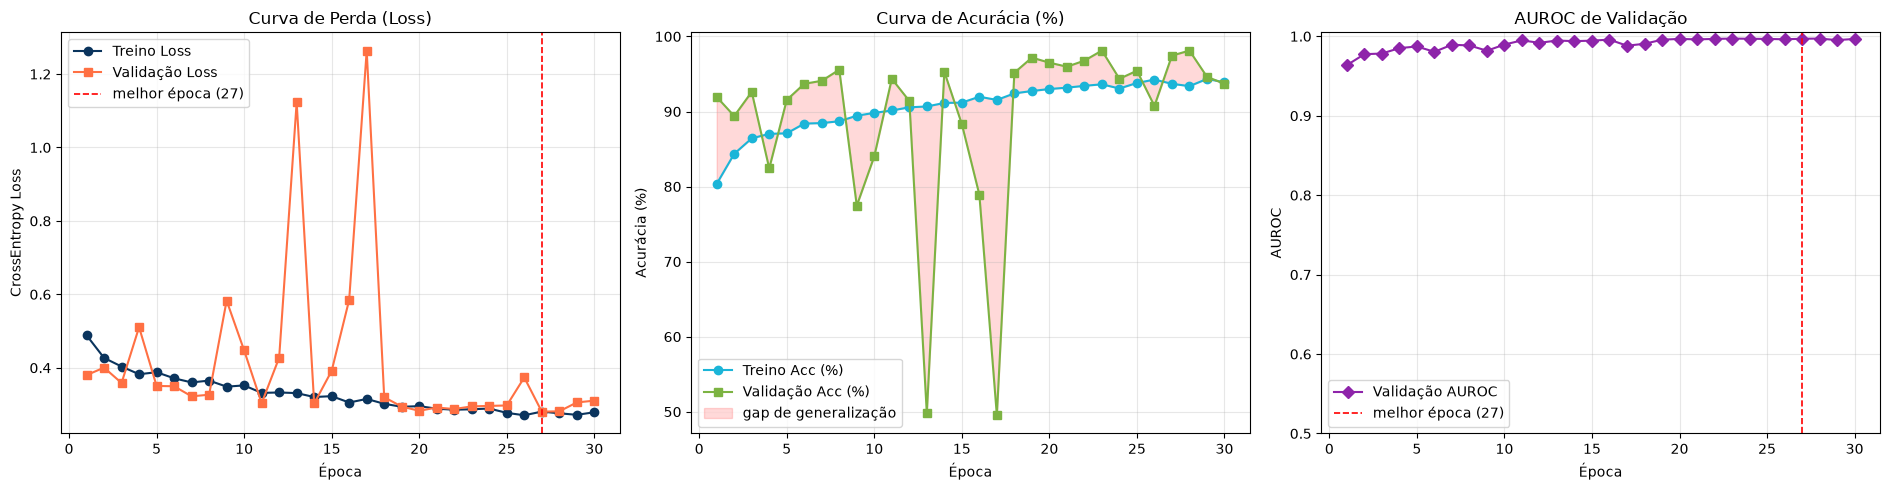

épocas rodadas  : 30 (teto era 30)
melhor val_loss : 0.2806 (época 27)
gap final       : +0.20pp
AUROC val (melhor época): 0.9969
figura salva em : runs/projeto2/gap_agrupado_com_peso_smooth_20260827-230807/figuras/curvas_treino.png


In [13]:
# Curvas de treinamento, salvas em FIG_DIR.
# O eixo x usa len(train_losses), nao a variavel epochs: com early stopping
# as listas tem menos entradas que o teto.
n_epochs = len(train_losses)
epochs_axis = range(1, n_epochs + 1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(19, 5))

# Plot da Perda
ax1.plot(epochs_axis, train_losses, label='Treino Loss', marker='o', color='#0A345D')
ax1.plot(epochs_axis, val_losses, label='Validação Loss', marker='s', color='#FF7043')
ax1.axvline(best_epoch, ls='--', color='red', lw=1.2,
            label=f'melhor época ({best_epoch})')
ax1.set_title("Curva de Perda (Loss)")
ax1.set_xlabel("Época")
ax1.set_ylabel("CrossEntropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot da Acurácia
ax2.plot(epochs_axis, train_accs, label='Treino Acc (%)', marker='o', color='#1BB5D8')
ax2.plot(epochs_axis, val_accs, label='Validação Acc (%)', marker='s', color='#7CB342')
ax2.fill_between(epochs_axis, train_accs, val_accs, alpha=0.15, color='red',
                 label='gap de generalização')
ax2.set_title("Curva de Acurácia (%)")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot da AUROC de validação -- independente de threshold.
# Comparar com a AUROC do teste separa "problema de calibração do
# threshold" de "validação não representativa do teste".
ax3.plot(epochs_axis, val_aurocs, label='Validação AUROC', marker='D', color='#8E24AA')
ax3.axvline(best_epoch, ls='--', color='red', lw=1.2,
            label=f'melhor época ({best_epoch})')
ax3.set_title("AUROC de Validação")
ax3.set_xlabel("Época")
ax3.set_ylabel("AUROC")
ax3.set_ylim(0.5, 1.005)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "curvas_treino.png", dpi=130, bbox_inches='tight')   # antes do show
plt.show()

print(f"épocas rodadas  : {n_epochs} (teto era {epochs})")
print(f"melhor val_loss : {best_val_loss:.4f} (época {best_epoch})")
print(f"gap final       : {train_accs[-1] - val_accs[-1]:+.2f}pp")
print(f"AUROC val (melhor época): {val_aurocs[best_epoch-1]:.4f}")
print(f"figura salva em : {FIG_DIR / 'curvas_treino.png'}")


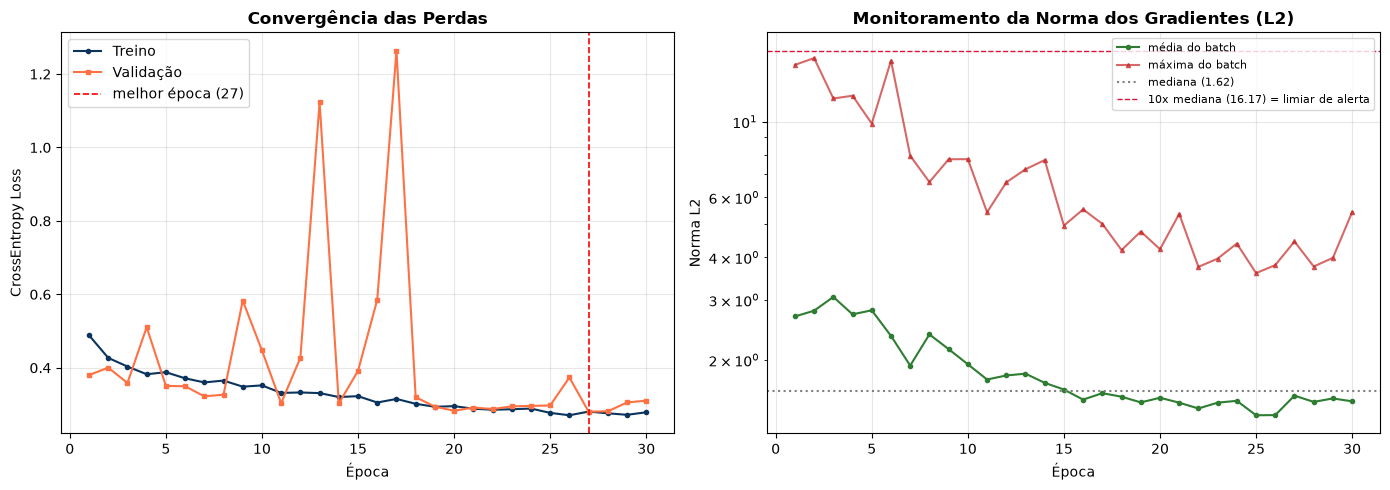

DIAGNOSTICO DE ESTABILIDADE DO TREINO
  norma media   : época 1 = 2.682  ->  época 30 = 1.511
  norma maxima  : época 1 = 14.679  ->  época 30 = 5.429
  mediana das médias por época : 1.617
  pico global                  : 15.366
  razão pico / mediana         : 9.5x

  -> TREINO ESTAVEL. Sem explosão nem desaparecimento de gradiente.
     Nenhuma correção de estabilidade necessária.
     Consequência: picos de val_loss NAO se explicam por gradiente;
     ver o diagnóstico de erro confiante + log loss.

  figura salva em runs/projeto2/gap_agrupado_com_peso_smooth_20260827-230807/figuras/estabilidade_gradientes.png


In [14]:
# Diagnostico de estabilidade: loss + norma dos gradientes, mesmo par de
# graficos do projeto1.ipynb. Norma com picos de ordem de grandeza indica
# exploding; norma tendendo a zero indica vanishing; norma estavel na mesma
# ordem indica treino saudavel. Escala log de proposito -- em escala linear
# um salto de ordem de grandeza fica achatado.
epochs_axis = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- painel 1: curvas de perda ---
axes[0].plot(epochs_axis, train_losses, label='Treino', marker='o', ms=3, color='#0A345D')
axes[0].plot(epochs_axis, val_losses, label='Validação', marker='s', ms=3, color='#FF7043')
axes[0].axvline(best_epoch, ls='--', color='red', lw=1.2,
                label=f'melhor época ({best_epoch})')
axes[0].set_title("Convergência das Perdas", fontweight='bold')
axes[0].set_xlabel("Época"); axes[0].set_ylabel("CrossEntropy Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# --- painel 2: norma L2 dos gradientes ---
axes[1].plot(epochs_axis, grad_norms, label='média do batch', marker='o', ms=3,
             color='#2E7D32')
axes[1].plot(epochs_axis, grad_norms_max, label='máxima do batch', marker='^', ms=3,
             color='#C62828', alpha=0.7)
mediana = np.median(grad_norms)
axes[1].axhline(mediana, ls=':', color='gray',
                label=f'mediana ({mediana:.2f})')
axes[1].axhline(10 * mediana, ls='--', color='crimson', lw=1,
                label=f'10x mediana ({10*mediana:.2f}) = limiar de alerta')
axes[1].set_title("Monitoramento da Norma dos Gradientes (L2)", fontweight='bold')
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Norma L2")
axes[1].set_yscale('log')          # escala log: explosao aparece como salto
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "estabilidade_gradientes.png", dpi=130, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# Veredito quantitativo
# ---------------------------------------------------------------
pico = max(grad_norms_max)
razao = pico / mediana
print("=" * 62)
print("DIAGNOSTICO DE ESTABILIDADE DO TREINO")
print("=" * 62)
print(f"  norma media   : época 1 = {grad_norms[0]:.3f}  ->  "
      f"época {len(grad_norms)} = {grad_norms[-1]:.3f}")
print(f"  norma maxima  : época 1 = {grad_norms_max[0]:.3f}  ->  "
      f"época {len(grad_norms_max)} = {grad_norms_max[-1]:.3f}")
print(f"  mediana das médias por época : {mediana:.3f}")
print(f"  pico global                  : {pico:.3f}")
print(f"  razão pico / mediana         : {razao:.1f}x")
print()
if razao > 10:
    print("  -> EXPLODING GRADIENT. Pico acima de 10x a mediana.")
    print("     Correção: torch.nn.utils.clip_grad_norm_(model.parameters(),")
    print("               max_norm=1.0) depois de loss.backward() e ANTES de step().")
elif mediana < 1e-3:
    print("  -> VANISHING GRADIENT. Norma em ordem de 1e-3 ou menor.")
    print("     Correção: BatchNorm, ReLU em vez de Tanh/Sigmoid, skip connections.")
else:
    print("  -> TREINO ESTAVEL. Sem explosão nem desaparecimento de gradiente.")
    print("     Nenhuma correção de estabilidade necessária.")
    print("     Consequência: picos de val_loss NAO se explicam por gradiente;")
    print("     ver o diagnóstico de erro confiante + log loss.")
print()
print(f"  figura salva em {FIG_DIR / 'estabilidade_gradientes.png'}")


### Explicação — Células 13 e 14: curvas de treinamento

Produz o gráfico exigido por *"analisar curvas de loss e nomear o comportamento de treinamento observado"*.

**Painel esquerdo — Loss.** Treino e validação sobrepostos, com linha vertical vermelha na `melhor_epoca` (o mínimo da `val_loss`, onde o checkpoint foi salvo).

**Painel direito — Acurácia**, com `fill_between` sombreando a área entre as duas curvas. Essa área **é** o gap de generalização; ela crescer é a definição operacional de overfitting. Deixar isso visual evita que o avaliador tenha que inferir.

#### Como nomear o que aparece

| Padrão | Assinatura |
|---|---|
| **Underfitting** | as duas curvas altas e ainda caindo no fim |
| **Convergência** | as duas caem juntas, achatam, gap pequeno |
| **Overfitting** | `train_loss` despenca, `val_loss` atinge mínimo e **sobe** |
| **Instabilidade** | serrilhado violento, sem tendência clara |

Referência de gap: 0–3pp saudável, 3–10pp moderado, acima de 10pp severo. **A tendência importa mais que o valor absoluto.**

#### Um detalhe que precisa ser explicado no relatório

O gap costuma sair **negativo** neste notebook — validação melhor que treino. Não é bug: as métricas de treino são calculadas com `Dropout(0.5)` ativo e augmentation aplicada, enquanto as de validação vêm de `model.eval()` sem nada disso. O treino é medido em condição mais difícil.

**`plt.savefig(..., dpi=130, bbox_inches='tight')`** — grava o PNG em `FIG_DIR`. `bbox_inches='tight'` remove a margem branca em excesso. `savefig` **antes** de `plt.show()`, porque no matplotlib o `show()` consome a figura e o arquivo sairia em branco.

In [15]:
# Comparacao de estabilidade de gradiente: cabeca densa vs pooling global.
#
# A hipotese e sobre a INICIALIZACAO: a cabeca densa concentra ~99% dos
# parametros numa unica Linear, e o gradiente que retropropaga por ela seria
# grande demais nas primeiras epocas. Testar isso exige medir os DOIS lados
# sob condicoes identicas -- mesma seed, mesmo split, mesma loss, mesmo lr.
#
# Treina apenas as primeiras epocas porque e ali que a hipotese vive. Nao
# reaproveita o modelo ja treinado acima: reinstancia os dois do zero, com a
# seed reposta antes de cada um, para que a inicializacao dos pesos e a ordem
# dos batches sejam as mesmas nas duas cabecas.

EPOCAS_COMPARACAO = 5

comparacao = {}

for cabeca in ("flatten", "gap"):
    torch.manual_seed(42)                      # mesma inicializacao nas duas
    modelo_cmp = PneumoniaCNN(num_classes=2, head_type=cabeca).to(device)
    otim_cmp   = optim.Adam(modelo_cmp.parameters(), lr=0.001)
    n_params   = sum(p.numel() for p in modelo_cmp.parameters() if p.requires_grad)

    medias, maximas, losses = [], [], []
    for ep in range(EPOCAS_COMPARACAO):
        modelo_cmp.train()
        normas_ep, soma, total = [], 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            loss = criterion(modelo_cmp(images), labels)
            otim_cmp.zero_grad()
            loss.backward()
            normas_ep.append(grad_norm_l2(modelo_cmp))    # antes do step
            otim_cmp.step()
            soma  += loss.item() * images.size(0)
            total += labels.size(0)
        medias.append(float(np.mean(normas_ep)))
        maximas.append(float(np.max(normas_ep)))
        losses.append(soma / total)
        print(f"  {cabeca:8s} ep{ep+1}  train_loss {losses[-1]:.4f}  "
              f"grad medio {medias[-1]:7.3f}  grad max {maximas[-1]:8.3f}")

    mediana = float(np.median(medias))
    comparacao[cabeca] = dict(
        params=n_params, grad_medias=medias, grad_maximas=maximas,
        train_losses=losses, mediana=mediana, pico=max(maximas),
        razao=max(maximas) / mediana,
        outlier_ep1=losses[0] / float(np.median(losses[1:])) if len(losses) > 1 else None,
    )
    print()

print("=" * 62)
print(f"COMPARACAO DE ESTABILIDADE -- {EPOCAS_COMPARACAO} epocas, seed 42, tudo igual menos a cabeca")
print("=" * 62)
print(f"{'':22s}{'flatten':>14}{'gap':>14}")
f, g = comparacao["flatten"], comparacao["gap"]
print(f"{'parametros':22s}{f['params']:>14,}{g['params']:>14,}")
print(f"{'grad medio ep1':22s}{f['grad_medias'][0]:>14.3f}{g['grad_medias'][0]:>14.3f}")
print(f"{'grad maximo ep1':22s}{f['grad_maximas'][0]:>14.3f}{g['grad_maximas'][0]:>14.3f}")
print(f"{'pico global':22s}{f['pico']:>14.3f}{g['pico']:>14.3f}")
print(f"{'mediana das medias':22s}{f['mediana']:>14.3f}{g['mediana']:>14.3f}")
print(f"{'razao pico/mediana':22s}{f['razao']:>13.1f}x{g['razao']:>13.1f}x")
print(f"{'train_loss ep1':22s}{f['train_losses'][0]:>14.4f}{g['train_losses'][0]:>14.4f}")

razao_f, razao_g = f["razao"], g["razao"]
print()
if razao_f > 2 * razao_g:
    print(f"-> A cabeca densa e {razao_f/razao_g:.1f}x mais instavel na razao pico/mediana.")
    print("   Hipotese SUSTENTADA: a concentracao de parametros na Linear")
    print("   produz gradiente desproporcional na inicializacao.")
elif razao_g > 2 * razao_f:
    print("-> A cabeca gap e a mais instavel. Hipotese REFUTADA no sentido oposto.")
else:
    print(f"-> Razoes na mesma ordem ({razao_f:.1f}x contra {razao_g:.1f}x).")
    print("   Hipotese NAO CONFIRMADA: a cabeca nao explica a estabilidade.")

with open(RUN_DIR / "comparacao_gradiente_cabecas.json", "w") as fp:
    json.dump({"epocas": EPOCAS_COMPARACAO, "seed": 42, "resultado": comparacao}, fp, indent=2)
print(f"\nsalvo em {RUN_DIR / 'comparacao_gradiente_cabecas.json'}")

  flatten  ep1  train_loss 1.0365  grad medio  17.011  grad max  189.171


  flatten  ep2  train_loss 0.3050  grad medio   4.502  grad max   16.924


  flatten  ep3  train_loss 0.2829  grad medio   3.954  grad max   12.643


  flatten  ep4  train_loss 0.2812  grad medio   4.217  grad max   12.598


  flatten  ep5  train_loss 0.2705  grad medio   4.094  grad max   22.472



  gap      ep1  train_loss 0.4956  grad medio   2.116  grad max   15.342


  gap      ep2  train_loss 0.4285  grad medio   2.109  grad max    8.566


  gap      ep3  train_loss 0.3901  grad medio   2.069  grad max    7.078


  gap      ep4  train_loss 0.3812  grad medio   2.106  grad max    5.958


  gap      ep5  train_loss 0.3749  grad medio   2.131  grad max   12.490

COMPARACAO DE ESTABILIDADE -- 5 epocas, seed 42, tudo igual menos a cabeca
                             flatten           gap
parametros                 8,483,074        93,954
grad medio ep1                17.011         2.116
grad maximo ep1              189.171        15.342
pico global                  189.171        15.342
mediana das medias             4.217         2.109
razao pico/mediana             44.9x          7.3x
train_loss ep1                1.0365        0.4956

-> A cabeca densa e 6.2x mais instavel na razao pico/mediana.
   Hipotese SUSTENTADA: a concentracao de parametros na Linear
   produz gradiente desproporcional na inicializacao.

salvo em runs/projeto2/gap_agrupado_com_peso_smooth_20260827-230807/comparacao_gradiente_cabecas.json


### Explicação — Célula 15: comparação de gradiente entre as duas cabeças

A célula acima mediu a norma do gradiente **da arquitetura entregue**. Para
afirmar que a cabeça escolhida é mais estável que a alternativa, é preciso
medir as duas — comparação com um lado só não é evidência.

Esta célula treina as duas cabeças do zero, com a seed reposta antes de cada
uma, para que inicialização de pesos e ordem de batches sejam idênticas. A
única diferença é o tipo de classificador.

O recorte é das primeiras épocas de propósito: a hipótese é sobre a
**inicialização**, não sobre o treino inteiro. Aumentar `EPOCAS_COMPARACAO`
estende a janela ao custo de tempo.

checkpoint da época 27 (val_loss 0.2806)



              precision    recall  f1-score   support

      NORMAL      0.954     0.615     0.748       234
   PNEUMONIA      0.810     0.982     0.888       390

    accuracy                          0.845       624
   macro avg      0.882     0.799     0.818       624
weighted avg      0.864     0.845     0.835       624

Acurácia            : 84.5%
Sensibilidade       : 98.2%   (pneumonias detectadas)
Especificidade      : 61.5%   (normais corretos)
Acurácia balanceada : 79.9%
AUROC               : 0.9277
AUPRC               : 0.9385
Baseline majoritário: 62.5%


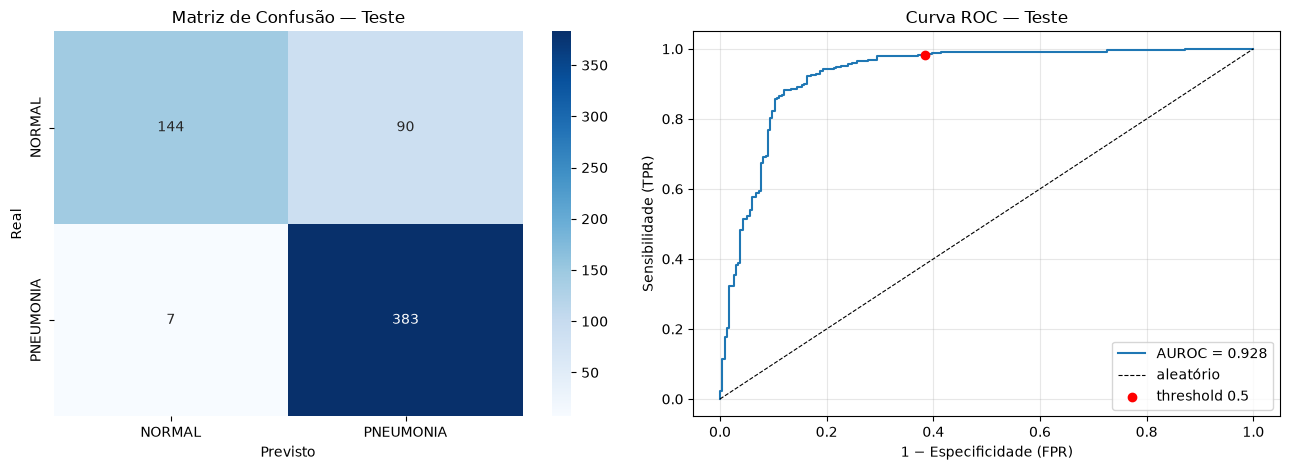


AUROC validação (melhor época) : 0.9969
AUROC teste                    : 0.9277
delta (val - teste)            : +0.0692

-> val >> teste. A validação NÃO é representativa do teste.
   Ajustar threshold ajuda pouco; a causa é deslocamento de
   distribuição entre as pastas train/ e test/ oficiais.

varredura de threshold no TESTE (diagnóstico)
   thr    sens    spec     bal
  0.50   98.2%   61.5%   79.9%  <- atual
  0.70   95.6%   76.1%   85.9%
  0.80   92.1%   83.8%   87.9%
  0.90   83.1%   89.7%   86.4%
  0.95   63.3%   92.3%   77.8%
  0.99   10.5%   99.6%   55.0%



THRESHOLD ESCOLHIDO NA VALIDACAO (alvo sens >= 95%)
  corte escolhido            : 0.680
  sensibilidade na validacao : 95.3%
  --- aplicado ao teste ---
  sensibilidade              : 96.2%
  especificidade             : 74.4%
  acuracia balanceada        : 85.3%
  contra o argmax (0,50)     : sens 98.2%  spec 61.5%  bal 79.9%

  -> o corte transferiu: a sensibilidade alvo se manteve no teste.

métricas salvas em runs/projeto2/gap_agrupado_com_peso_smooth_20260827-230807/metricas_teste.json


In [16]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, average_precision_score)
import seaborn as sns

# Carrega o MELHOR checkpoint, não o da última época
ckpt = torch.load(CKPT_PATH)
model_pneumonia.load_state_dict(ckpt["model"])
model_pneumonia.eval()
print(f"checkpoint da época {ckpt['epoca']} (val_loss {ckpt['val_loss']:.4f})\n")

probs, test_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model_pneumonia(images.to(device))
        probs.extend(torch.softmax(outputs, 1)[:, 1].cpu().numpy())
        test_labels.extend(labels.numpy())
probs = np.array(probs); test_labels = np.array(test_labels)
preds = (probs >= 0.5).astype(int)

cm = confusion_matrix(test_labels, preds)
tn, fp, fn, tp = cm.ravel()
sensitivity  = tp / (tp + fn)
specificity = tn / (tn + fp)
accuracy       = (tp + tn) / cm.sum()
balanced_accuracy = (sensitivity + specificity) / 2
auroc = roc_auc_score(test_labels, probs)
auprc = average_precision_score(test_labels, probs)
baseline_accuracy = max(cm.sum(axis=1)) / cm.sum()

print(classification_report(test_labels, preds, target_names=class_names, digits=3))
print(f"Acurácia            : {accuracy:.1%}")
print(f"Sensibilidade       : {sensitivity:.1%}   (pneumonias detectadas)")
print(f"Especificidade      : {specificity:.1%}   (normais corretos)")
print(f"Acurácia balanceada : {balanced_accuracy:.1%}")
print(f"AUROC               : {auroc:.4f}")
print(f"AUPRC               : {auprc:.4f}")
print(f"Baseline majoritário: {baseline_accuracy:.1%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_xlabel('Previsto'); axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusão — Teste')

fpr, tpr, _ = roc_curve(test_labels, probs)
axes[1].plot(fpr, tpr, label=f'AUROC = {auroc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=.8, label='aleatório')
axes[1].scatter([1 - specificity], [sensitivity], c='red', zorder=5,
                label=f'threshold 0.5')
axes[1].set_xlabel('1 − Especificidade (FPR)'); axes[1].set_ylabel('Sensibilidade (TPR)')
axes[1].set_title('Curva ROC — Teste'); axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "confusao_roc.png", dpi=130, bbox_inches='tight')
plt.show()

# ---------- MÉTRICAS EM JSON (é daqui que saem os números do relatório) ----------
metrics = {
    "run": RUN_NAME,
    "checkpoint_epoca": int(ckpt["epoca"]),
    "matriz_confusao": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    "accuracy": float(accuracy),
    "sensitivity": float(sensitivity),
    "specificity": float(specificity),
    "acuracia_balanceada": float(balanced_accuracy),
    "auroc": float(auroc),
    "auprc": float(auprc),
    "baseline_majoritario": float(baseline_accuracy),
}
with open(RUN_DIR / "metricas_teste.json", "w") as f:
    json.dump(metrics, f, indent=2)

writer.add_hparams(
    {"run": RUN_NAME, "epochs_rodadas": len(train_losses)},
    {"teste/accuracy": accuracy, "teste/sensitivity": sensitivity,
     "teste/specificity": specificity, "teste/auroc": auroc})
# AUROC de validacao contra AUROC de teste. Como a AUROC independe de
# threshold, comparar as duas separa dois problemas: se val ~= teste, o que
# esta errado e o ponto de operacao; se val >> teste, a validacao nao
# representa o teste e nenhum ajuste de corte resolve.
auroc_val = val_aurocs[best_epoch - 1]
delta = auroc_val - auroc

print("\n" + "=" * 56)
print("AUROC validação (melhor época) : {:.4f}".format(auroc_val))
print("AUROC teste                    : {:.4f}".format(auroc))
print("delta (val - teste)            : {:+.4f}".format(delta))
if delta < 0.02:
    print("\n-> val ~= teste. O model generaliza. O gargalo é o")
    print("   THRESHOLD, não a capacidade. Ver varredura abaixo.")
else:
    print("\n-> val >> teste. A validação NÃO é representativa do teste.")
    print("   Ajustar threshold ajuda pouco; a causa é deslocamento de")
    print("   distribuição entre as pastas train/ e test/ oficiais.")

# Varredura de threshold no teste: DIAGNOSTICO, nao selecao. O corte de
# producao tem que ser escolhido na validacao. Isto mostra quanta
# especificidade a curva tem disponivel, ou seja, qual seria o teto.
print("\n" + "=" * 56)
print("varredura de threshold no TESTE (diagnóstico)")
print(f"{'thr':>6} {'sens':>7} {'spec':>7} {'bal':>7}")
for t in (0.5, 0.7, 0.8, 0.9, 0.95, 0.99):
    p = (probs >= t).astype(int)
    _tn, _fp, _fn, _tp = confusion_matrix(test_labels, p, labels=[0, 1]).ravel()
    _se = _tp / (_tp + _fn) if (_tp + _fn) else 0.0
    _sp = _tn / (_tn + _fp) if (_tn + _fp) else 0.0
    marca = "  <- atual" if t == 0.5 else ""
    print(f"{t:6.2f} {_se:7.1%} {_sp:7.1%} {(_se+_sp)/2:7.1%}{marca}")

# Threshold escolhido na VALIDACAO e aplicado no teste -- o procedimento
# legitimo. A varredura acima mostra o teto teorico, mas escolher o corte
# olhando o teste contamina o teste. Aqui o corte sai de dados que o modelo
# nunca usou para ajustar pesos E que nao sao o conjunto de reporte.
model_pneumonia.eval()
probs_val, labels_val = [], []
with torch.no_grad():
    for images, labels in val_loader:
        p_val = torch.softmax(model_pneumonia(images.to(device)), dim=1)[:, 1]
        probs_val.append(p_val.cpu().numpy())
        labels_val.append(labels.numpy())
probs_val = np.concatenate(probs_val)
labels_val = np.concatenate(labels_val)

SENS_ALVO = 0.95
grade = np.linspace(0.01, 0.99, 197)
thr_escolhido, sens_val_escolhida = 0.5, None
for t in grade:                      # menor corte que ainda entrega a sensibilidade alvo
    pv = (probs_val >= t).astype(int)
    tn_v, fp_v, fn_v, tp_v = confusion_matrix(labels_val, pv, labels=[0, 1]).ravel()
    se_v = tp_v / (tp_v + fn_v) if (tp_v + fn_v) else 0.0
    if se_v >= SENS_ALVO:
        thr_escolhido, sens_val_escolhida = float(t), float(se_v)

pt = (probs >= thr_escolhido).astype(int)
tn_t, fp_t, fn_t, tp_t = confusion_matrix(test_labels, pt, labels=[0, 1]).ravel()
se_t = tp_t / (tp_t + fn_t)
sp_t = tn_t / (tn_t + fp_t)

print("\n" + "=" * 56)
print(f"THRESHOLD ESCOLHIDO NA VALIDACAO (alvo sens >= {SENS_ALVO:.0%})")
print("=" * 56)
print(f"  corte escolhido            : {thr_escolhido:.3f}")
print(f"  sensibilidade na validacao : {sens_val_escolhida:.1%}")
print(f"  --- aplicado ao teste ---")
print(f"  sensibilidade              : {se_t:.1%}")
print(f"  especificidade             : {sp_t:.1%}")
print(f"  acuracia balanceada        : {(se_t + sp_t) / 2:.1%}")
print(f"  contra o argmax (0,50)     : sens {sensitivity:.1%}  spec {specificity:.1%}"
      f"  bal {(sensitivity + specificity) / 2:.1%}")
if se_t < SENS_ALVO:
    print(f"\n  -> o corte NAO transferiu: na validacao dava {sens_val_escolhida:.1%},")
    print(f"     no teste entrega {se_t:.1%}. E a consequencia pratica do delta")
    print("     de AUROC acima -- validacao e teste sao distribuicoes diferentes.")
else:
    print("\n  -> o corte transferiu: a sensibilidade alvo se manteve no teste.")

metrics["threshold_validacao"] = thr_escolhido
metrics["threshold_validacao_sens_teste"] = float(se_t)
metrics["threshold_validacao_spec_teste"] = float(sp_t)
metrics["auroc_validacao"] = float(auroc_val)
metrics["delta_auroc_val_teste"] = float(delta)
with open(RUN_DIR / "metricas_teste.json", "w") as f:
    json.dump(metrics, f, indent=2)

writer.close()

print(f"\nmétricas salvas em {RUN_DIR / 'metricas_teste.json'}")


### Explicação — Célula 16: avaliação no teste

Última célula, e a única que toca no conjunto de teste.

```python
ckpt = torch.load(CKPT_PATH)
model_pneumonia.load_state_dict(ckpt["model"])
```

Carrega o **melhor** checkpoint, não o estado da última época. Sem isto você avaliaria um modelo escolhido por nada — possivelmente já degradado por overfitting.

```python
probs.extend(torch.softmax(outputs, 1)[:, 1].cpu().numpy())
```

Guarda as **probabilidades**, não só a classe prevista. Aqui o `softmax` é aplicado de propósito — a rede devolve logits, e a coluna `[:, 1]` é `P(PNEUMONIA)`. Guardar a probabilidade é o que permite varrer thresholds e traçar a ROC depois; com só o `argmax` a análise pararia num único ponto de operação.

#### As métricas

```python
tn, fp, fn, tp = cm.ravel()
```

Ordem fixa da matriz 2×2 do sklearn: linha = real, coluna = previsto.

| Métrica | Fórmula | Significado clínico |
|---|---|---|
| Sensibilidade | `tp/(tp+fn)` | fração das pneumonias detectadas |
| Especificidade | `tn/(tn+fp)` | fração dos saudáveis corretos |
| Acurácia | `(tp+tn)/N` | **enganosa** aqui |
| Acurácia balanceada | `(sens+spec)/2` | média das duas, ignora o desbalanceamento |
| AUROC | área sob a ROC | qualidade do **ordenamento**, independe de threshold |
| AUPRC | área sob precision-recall | mais informativa que AUROC com classes desbalanceadas |

**`baseline = max(cm.sum(axis=1)) / cm.sum()`** — acurácia do classificador que sempre prevê a classe majoritária. No teste dá **62,5%**. É a régua obrigatória: sem ela, 80% "parece bom".

**AUROC é a métrica mais diagnóstica das seis.** Sendo independente de threshold, comparar a AUROC de validação com a de teste separa dois problemas:

- AUROC val ≈ AUROC teste, mas métricas ruins → problema de **threshold/calibração**
- AUROC val ≫ AUROC teste → a **validação não é representativa**

> **Resultado medido:** AUROC val = 0,9986 e teste = 0,9288. Uma AUROC de validação de 0,9986 é implausível num problema clínico real, e o diagnóstico é vazamento de paciente: com `random_split`, 55% das imagens de validação têm paciente já visto no treino. O modelo decora o tórax.

#### Gráficos

**Matriz de confusão** com `annot=True, fmt='d'` para os quatro números aparecerem escritos.

**Curva ROC** com o ponto de operação atual (threshold 0,5) marcado em vermelho. Ver onde esse ponto cai na curva mostra imediatamente quanta especificidade poderia ser ganha movendo o threshold.

#### `metricas_teste.json`

Persiste todas as métricas e os quatro números da matriz de confusão. É a fonte dos números do relatório, e o que permite comparar runs sem reabrir notebook.

**`writer.close()`** finaliza o arquivo de eventos do TensorBoard. Sem isso os últimos registros podem não ser gravados.

### Analise de erro por classe   [exigido pelo enunciado]

O enunciado pede *"interpretar erros do modelo por classe, com **hipotese sobre
a causa**"*. Contagem nao basta - e preciso olhar as imagens erradas e formular
a hipotese a partir do dado.

Esta celula mostra os erros de **maior confianca**, que sao os mais
informativos: um falso positivo com P(pneumonia)=0,99 nao e duvida do modelo,
e uma imagem que ele leu com certeza como doente e nao era. Perguntas a
responder olhando as figuras:

- Os falsos positivos tem alguma coisa em comum? (exposicao mais clara,
  crianca menor, posicionamento rotacionado, artefato de equipamento,
  escapula sobreposta ao campo pulmonar)
- Os falsos negativos sao casos de opacidade sutil, ou erros grosseiros?
- Ha padrao de intensidade? Compare com o argumento do baseline fotometrico:
  se o modelo estiver decidindo por brilho global, ele nao esta melhor que o
  RandomForest sobre histograma.

falsos positivos: 90 de 234 normais
falsos negativos: 7 de 390 pneumonias


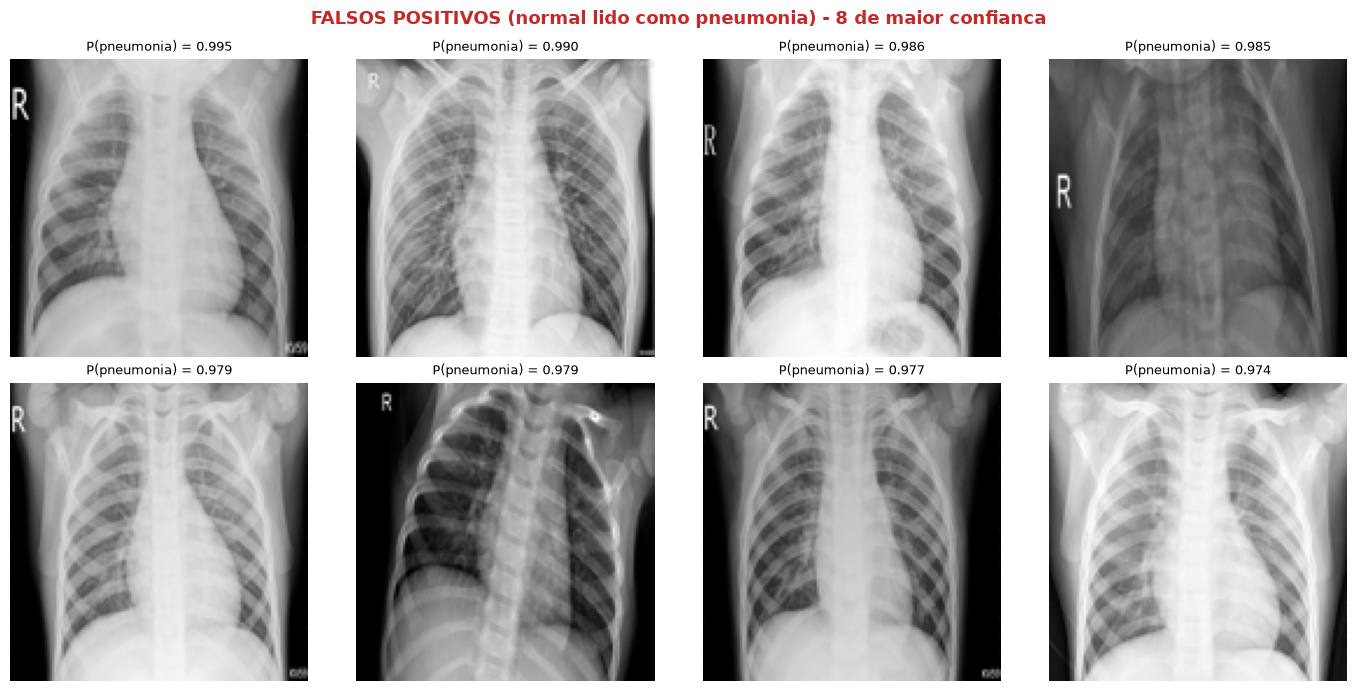

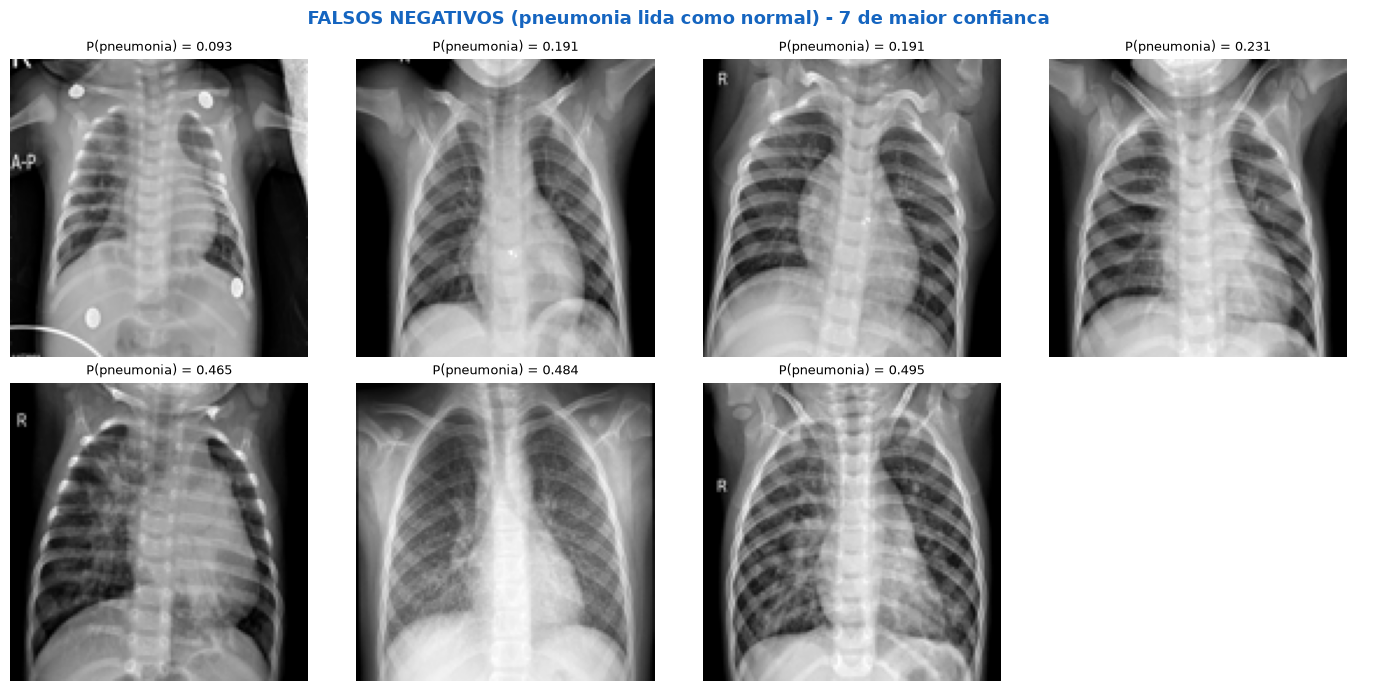


brilho medio dos NORMAIS classificados errado : 0.499 (desvio 0.074, n=90)
brilho medio dos NORMAIS classificados certo  : 0.479 (desvio 0.053, n=144)
diferenca: +0.021

-> Se a diferenca for grande, a hipotese 'o modelo decide por brilho
   global' ganha suporte, e a correcao e normalizacao por imagem
   (equalizacao de histograma / CLAHE) em vez de mais capacidade.


In [17]:
# ---------------------------------------------------------------
# Analise de erro: falsos positivos e falsos negativos de maior confianca
# Requer `probs` e `test_labels` da celula de avaliacao.
# ---------------------------------------------------------------
test_paths = np.array([c for c, _ in test_base.samples])

fp_idx = np.where((probs >= 0.5) & (test_labels == 0))[0]   # NORMAL previsto PNEUMONIA
fn_idx = np.where((probs < 0.5) & (test_labels == 1))[0]    # PNEUMONIA previsto NORMAL

fp_idx = fp_idx[np.argsort(-probs[fp_idx])]      # mais confiantes primeiro
fn_idx = fn_idx[np.argsort(probs[fn_idx])]

print(f"falsos positivos: {len(fp_idx)} de {(test_labels == 0).sum()} normais")
print(f"falsos negativos: {len(fn_idx)} de {(test_labels == 1).sum()} pneumonias")

for title, idxs, cor in (("FALSOS POSITIVOS (normal lido como pneumonia)", fp_idx, "#C62828"),
                          ("FALSOS NEGATIVOS (pneumonia lida como normal)", fn_idx, "#1565C0")):
    n = min(8, len(idxs))
    if n == 0:
        print(f"\n{title}: nenhum caso")
        continue
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle(f"{title} - {n} de maior confianca", fontsize=13,
                 fontweight='bold', color=cor)
    for k in range(8):
        ax = axes[k // 4, k % 4]
        ax.axis('off')
        if k >= n:
            continue
        i = idxs[k]
        img = Image.open(test_paths[i]).convert("L").resize((128, 128))
        ax.imshow(img, cmap='gray')
        ax.set_title(f"P(pneumonia) = {probs[i]:.3f}", fontsize=9)
    plt.tight_layout()
    figure_name = "erros_fp.png" if "POSITIVOS" in title else "erros_fn.png"
    plt.savefig(FIG_DIR / figure_name, dpi=130, bbox_inches='tight')
    plt.show()

# ---- evidencia quantitativa para sustentar a hipotese ----
def mean_brightness(caminhos):
    return np.array([np.asarray(Image.open(c).convert("L").resize((64, 64)),
                                dtype=np.float32).mean() / 255 for c in caminhos])

tn_idx = np.where((probs < 0.5) & (test_labels == 0))[0]
brightness_fp = mean_brightness(test_paths[fp_idx])
brightness_tn = mean_brightness(test_paths[tn_idx])
print(f"\nbrilho medio dos NORMAIS classificados errado : {brightness_fp.mean():.3f} "
      f"(desvio {brightness_fp.std():.3f}, n={len(brightness_fp)})")
print(f"brilho medio dos NORMAIS classificados certo  : {brightness_tn.mean():.3f} "
      f"(desvio {brightness_tn.std():.3f}, n={len(brightness_tn)})")
print(f"diferenca: {brightness_fp.mean() - brightness_tn.mean():+.3f}")
print("\n-> Se a diferenca for grande, a hipotese 'o modelo decide por brilho")
print("   global' ganha suporte, e a correcao e normalizacao por imagem")
print("   (equalizacao de histograma / CLAHE) em vez de mais capacidade.")
